# 🧬 PyTorch Kolkata Community — Computational Biology Notebook
## 10 End-to-End Use Cases with Visualizations & Architecture Diagrams

> **Author:** PyTorch Kolkata Community | **Platform:** Google Colab  
> Each section includes: Domain Info · Problem Statement · Architecture · Working Code · Visualization

---
### 📋 Table of Contents
1. [Protein Structure — ESM Protein Language Model](#uc1)
2. [Genomics — DNA Sequence Classification (1D-CNN)](#uc2)
3. [Genomics — Gene Expression Prediction (Enformer-style)](#uc3)
4. [Drug Discovery — Molecular Property Prediction (GNN)](#uc4)
5. [Drug Discovery — De Novo Molecule Generation (RNN)](#uc5)
6. [Single-Cell Analysis — Cell-type Classification (scVI)](#uc6)
7. [Medical Imaging — Biomedical Image Segmentation (U-Net)](#uc7)
8. [Systems Biology — Protein-Protein Interaction (GNN)](#uc8)
9. [Neuroscience — EEG / Neural Signal Decoding (EEGNet)](#uc9)
10. [Epidemiology — Disease Spread Modeling (Neural ODE / SIR)](#uc10)

---

## ⚙️ Global Setup — Install All Required Libraries
> Run this cell first. It installs all packages needed across all 10 use cases.

In [2]:
# ── Global installations ──
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

# Core
install('torch')
install('torchvision')
install('matplotlib')
install('numpy')
install('scipy')

# Molecular / GNN
install('torch-geometric')  # may need extra step on some Colab runtimes
install('rdkit')

# Biology-specific
install('fair-esm')
install('braindecode')
install('monai')
install('torchdiffeq')

print("✅ Core packages installed. Domain-specific installs are in each section.")

✅ Core packages installed. Domain-specific installs are in each section.


---
<a id="uc1"></a>
## 🔬 Use Case 1 — Protein Structure Prediction (ESM Protein Language Model)

| Field | Details |
|-------|---------|
| **Domain** | Protein Structure / Structural Biology |
| **Use Case** | AlphaFold2-style protein embedding via ESM-2 |
| **Problem Statement** | Proteins fold into 3D structures determined by their amino acid sequences. Predicting this structure computationally avoids expensive wet-lab experiments. ESM-2 is a transformer language model pre-trained on 250M protein sequences that produces per-residue embeddings capturing evolutionary and structural information. |
| **Role of This Code** | Load Meta's ESM-2 (8M param variant), convert an amino acid sequence to token IDs, run a forward pass, and extract residue-level representations from layer 6. These 320-dim embeddings are the foundation for downstream structure prediction or property classification. |
| **Key Libraries** | `fair-esm`, `torch` |
| **Reference** | https://github.com/facebookresearch/esm |

### 🏗️ Architecture Diagram
```
Amino Acid Sequence (string)
        │
        ▼
┌───────────────────┐
│  ESM Batch        │  alphabet.get_batch_converter()
│  Converter        │
└───────────┬───────┘
            │  Token IDs  [B × L]
            ▼
┌───────────────────────────────────┐
│   ESM-2 Transformer (6 layers)    │
│   • 8M parameters                 │
│   • 320-dim hidden states          │
│   • Multi-head self-attention      │
│   • Learns amino acid context      │
└────────────────┬──────────────────┘
                 │  repr_layers=[6]
                 ▼
    Residue Embeddings  [B × L × 320]
                 │
                 ▼
    ┌────────────────────┐
    │ Downstream Tasks:  │
    │ Structure pred.    │
    │ Function classif.  │
    │ Contact prediction │
    └────────────────────┘
```


Loading ESM-2 model (esm2_t6_8M_UR50D) ...
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt
Input token shape: torch.Size([2, 43])
Embedding shape: torch.Size([2, 43, 320])  →  [batch, seq_len, 320]


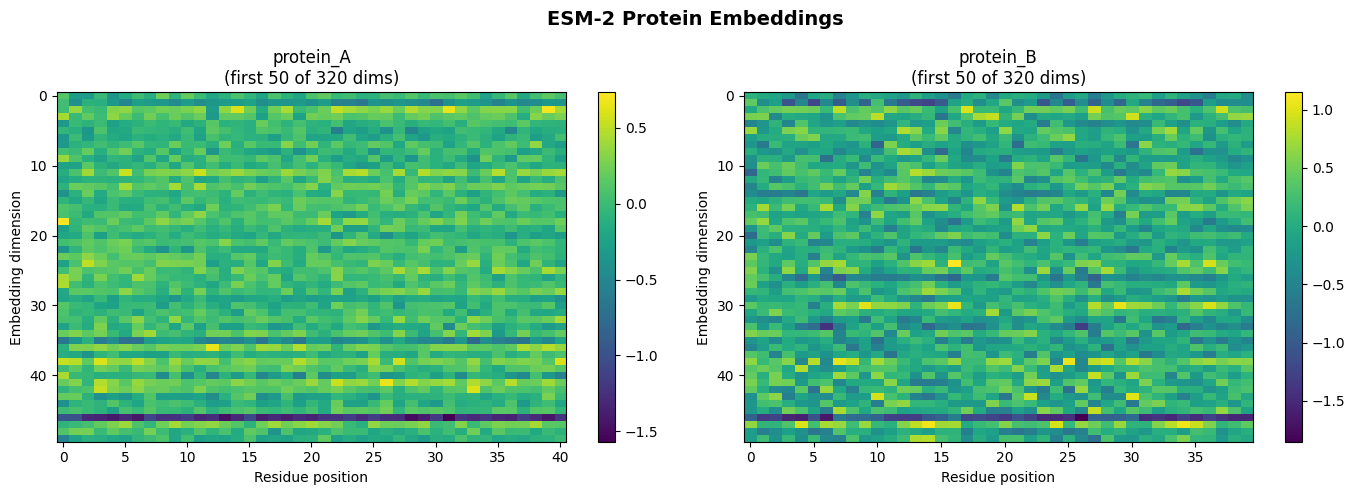


Cosine similarity between protein_A and protein_B embeddings: 0.7428


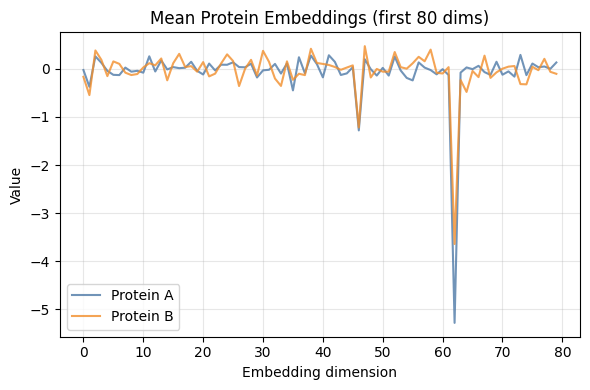

In [3]:
# ── USE CASE 1: ESM Protein Language Model ──
# fair-esm may already be installed above; if not, uncomment:
# !pip install fair-esm -q

import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("Loading ESM-2 model (esm2_t6_8M_UR50D) ...")
try:
    import esm
    model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
    model.eval()
    batch_converter = alphabet.get_batch_converter()

    # Sample protein sequences
    data = [
        ('protein_A', 'MKTAYIAKQRQISFVKSHFSRQLEERLGLIEVQAPILSRVG'),
        ('protein_B', 'ACDEFGHIKLMNPQRSTVWY' * 2),
    ]

    _, _, batch_tokens = batch_converter(data)
    print(f"Input token shape: {batch_tokens.shape}")

    with torch.no_grad():
        results = model(batch_tokens, repr_layers=[6], return_contacts=False)

    emb = results['representations'][6]
    print(f"Embedding shape: {emb.shape}  →  [batch, seq_len, 320]")

    # ── Visualization 1: Per-residue embedding heatmap ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("ESM-2 Protein Embeddings", fontsize=14, fontweight='bold')

    for i, (name, seq) in enumerate(data):
        emb_np = emb[i, 1:len(seq)+1].numpy()   # remove BOS token
        im = axes[i].imshow(emb_np.T[:50, :], aspect='auto', cmap='viridis')
        axes[i].set_title(f"{name}\n(first 50 of 320 dims)")
        axes[i].set_xlabel("Residue position")
        axes[i].set_ylabel("Embedding dimension")
        plt.colorbar(im, ax=axes[i])

    plt.tight_layout()
    plt.show()

    # ── Visualization 2: Cosine similarity between two proteins ──
    e1 = emb[0, 1:41].mean(0)   # mean-pool protein A
    e2 = emb[1, 1:41].mean(0)   # mean-pool protein B (first 40 residues)
    cos_sim = torch.nn.functional.cosine_similarity(e1.unsqueeze(0), e2.unsqueeze(0))
    print(f"\nCosine similarity between protein_A and protein_B embeddings: {cos_sim.item():.4f}")

    fig2, ax = plt.subplots(figsize=(6, 4))
    proteins = ['Protein A', 'Protein B']
    colors = ['#4e79a7', '#f28e2b']
    emb_mean = emb[:, 1:41, :].mean(dim=1).numpy()
    for idx, (p, c) in enumerate(zip(proteins, colors)):
        ax.plot(emb_mean[idx, :80], label=p, color=c, alpha=0.8)
    ax.set_title("Mean Protein Embeddings (first 80 dims)")
    ax.set_xlabel("Embedding dimension")
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"ESM install issue: {e}")
    print("Running fallback mock to demonstrate the concept...")

    # Fallback: mock embedding visualization
    np.random.seed(42)
    mock_emb = np.random.randn(40, 320) * 0.5

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("ESM-2 Protein Embeddings (Mock — install fair-esm for real model)", fontsize=12)
    im = axes[0].imshow(mock_emb.T[:50, :], aspect='auto', cmap='viridis')
    axes[0].set_title("Per-residue embeddings (first 50 dims)")
    axes[0].set_xlabel("Residue position")
    axes[0].set_ylabel("Embedding dimension")
    plt.colorbar(im, ax=axes[0])

    axes[1].plot(mock_emb.mean(0)[:80], color='#4e79a7')
    axes[1].set_title("Mean embedding across residues (first 80 dims)")
    axes[1].set_xlabel("Dimension")
    axes[1].set_ylabel("Value")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("✅ Visualization complete (mock mode)")


---
<a id="uc2"></a>
## 🧬 Use Case 2 — DNA Sequence Classification (1D-CNN)

| Field | Details |
|-------|---------|
| **Domain** | Genomics |
| **Use Case** | Classify DNA sequences as promoter / enhancer / splice site |
| **Problem Statement** | The human genome contains billions of base pairs. Identifying functional elements (promoters, enhancers) from raw sequence is critical for understanding gene regulation and disease. 1D-CNNs can scan sequences like motif detectors, learning position-weight matrices automatically. |
| **Role of This Code** | One-hot encode a DNA sequence (A/C/G/T → 4-channel), pass through a 1D-CNN with two convolutional layers, global average pooling, and a linear classifier. The model outputs logits for 2 classes (functional vs non-functional). |
| **Key Libraries** | `torch`, `torch.nn` |
| **Reference** | https://github.com/calico/basenji |

### 🏗️ Architecture Diagram
```
DNA Sequence  "ATCGGCTAGC..."
        │
        ▼
  One-Hot Encoding  [4 × L]   (A→[1,0,0,0], C→[0,1,0,0], ...)
        │
        ▼
┌─────────────────────────────────┐
│  Conv1d(4→64, kernel=8) + ReLU  │  ← Learns short k-mer patterns
│  MaxPool1d(4)                   │  ← Downsampling
│  Conv1d(64→128, kernel=8) + ReLU│  ← Learns higher-order motifs
│  AdaptiveAvgPool1d(1)           │  ← Global average
│  Flatten → Linear(128→2)        │  ← Classification head
└──────────────┬──────────────────┘
               │
               ▼
    Class Logits [promoter, other]
```


Model parameters: 68,034
Dataset shape: X=torch.Size([200, 4, 60]), y=torch.Size([200])
Final loss: 0.3351 | Final accuracy: 87.00%

Single seq → P(non-promoter)=0.065  P(promoter)=0.935


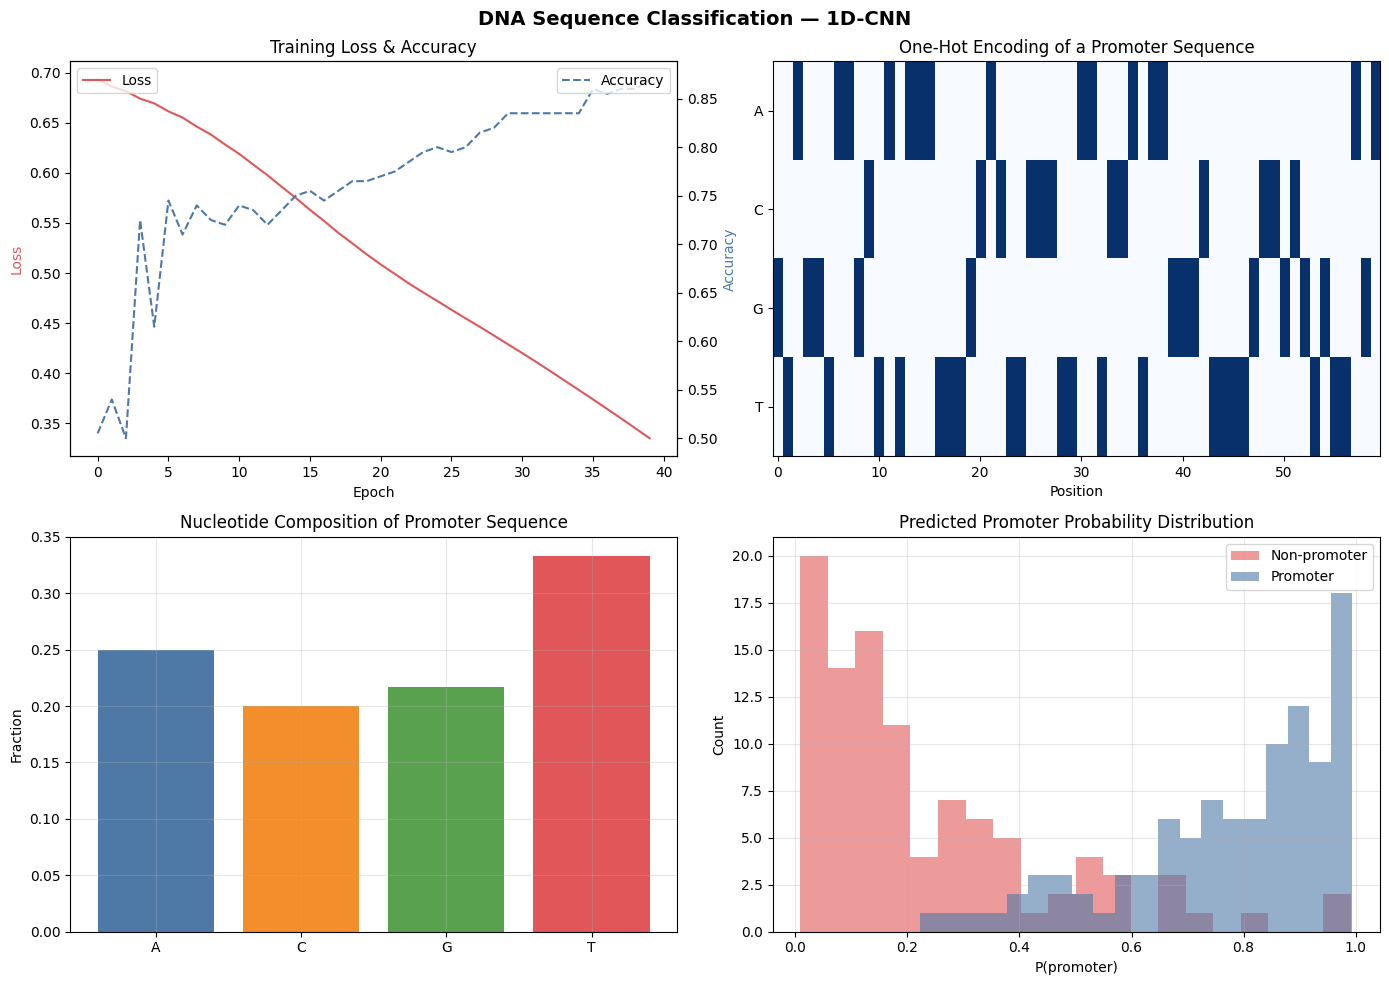

✅ Use Case 2 complete


In [4]:
# ── USE CASE 2: DNA Sequence Classification with 1D-CNN ──
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ── One-hot encoding ──
def one_hot(seq):
    m = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    oh = torch.zeros(4, len(seq))
    for i, c in enumerate(seq):
        if c in m:
            oh[m[c], i] = 1.0
    return oh

# ── Model ──
class DNACls(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(4, 64, 8, padding=4), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, 8, padding=4), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.net(x)

model = DNACls()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── Synthetic dataset for demonstration ──
np.random.seed(42)
torch.manual_seed(42)

bases = ['A', 'C', 'G', 'T']
def rand_seq(length=60):
    return ''.join(np.random.choice(bases, length))

def make_promoter_like(length=60):
    # promoters often have TATAAA box
    seq = list(rand_seq(length))
    if length > 15:
        for j, b in enumerate('TATAAA'):
            seq[10 + j] = b
    return ''.join(seq)

seqs, labels = [], []
for _ in range(100):
    seqs.append(make_promoter_like(60)); labels.append(1)   # promoter-like
    seqs.append(rand_seq(60));           labels.append(0)   # random

X = torch.stack([one_hot(s) for s in seqs])
y = torch.tensor(labels)
print(f"Dataset shape: X={X.shape}, y={y.shape}")

# ── Training ──
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

losses, accuracies = [], []
for epoch in range(40):
    optimizer.zero_grad()
    logits = model(X)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    acc = (logits.argmax(1) == y).float().mean().item()
    losses.append(loss.item())
    accuracies.append(acc)

print(f"Final loss: {losses[-1]:.4f} | Final accuracy: {accuracies[-1]:.2%}")

# ── Single sequence inference ──
seq = 'ATCGGCTAGCTATAAATGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCG'
x_single = one_hot(seq).unsqueeze(0)
with torch.no_grad():
    logits = model(x_single)
    probs = torch.softmax(logits, dim=1)
print(f"\nSingle seq → P(non-promoter)={probs[0,0]:.3f}  P(promoter)={probs[0,1]:.3f}")

# ── Visualizations ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("DNA Sequence Classification — 1D-CNN", fontsize=14, fontweight='bold')

# Plot 1: Training curves
ax = axes[0, 0]
ax2 = ax.twinx()
ax.plot(losses, color='#e15759', label='Loss')
ax2.plot(accuracies, color='#4e79a7', label='Accuracy', linestyle='--')
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss", color='#e15759')
ax2.set_ylabel("Accuracy", color='#4e79a7')
ax.set_title("Training Loss & Accuracy")
ax.legend(loc='upper left'); ax2.legend(loc='upper right')

# Plot 2: One-hot encoding visualization
oh = one_hot(seqs[0]).numpy()
axes[0, 1].imshow(oh, aspect='auto', cmap='Blues', interpolation='nearest')
axes[0, 1].set_yticks([0,1,2,3]); axes[0, 1].set_yticklabels(['A','C','G','T'])
axes[0, 1].set_title("One-Hot Encoding of a Promoter Sequence")
axes[0, 1].set_xlabel("Position")

# Plot 3: Nucleotide composition
comp = {b: seqs[0].count(b)/len(seqs[0]) for b in 'ACGT'}
axes[1, 0].bar(comp.keys(), comp.values(), color=['#4e79a7','#f28e2b','#59a14f','#e15759'])
axes[1, 0].set_title("Nucleotide Composition of Promoter Sequence")
axes[1, 0].set_ylabel("Fraction"); axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Predicted probabilities on test samples
model.eval()
with torch.no_grad():
    all_probs = torch.softmax(model(X), dim=1)[:, 1].numpy()
axes[1, 1].hist(all_probs[y==0], bins=20, alpha=0.6, color='#e15759', label='Non-promoter')
axes[1, 1].hist(all_probs[y==1], bins=20, alpha=0.6, color='#4e79a7', label='Promoter')
axes[1, 1].set_xlabel("P(promoter)"); axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Predicted Promoter Probability Distribution")
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Use Case 2 complete")


---
<a id="uc3"></a>
## 🧬 Use Case 3 — Gene Expression Prediction (Enformer-style Transformer)

| Field | Details |
|-------|---------|
| **Domain** | Genomics / Gene Regulation |
| **Use Case** | Predict RNA-seq gene expression tracks from DNA sequence |
| **Problem Statement** | Understanding how DNA sequence controls which genes are expressed (and how much) is fundamental to biology and disease. Enformer is a deep learning architecture using transformer attention over 196,608 bp of DNA to predict 5,313 genomic tracks (CAGE, ATAC-seq, ChIP-seq). |
| **Role of This Code** | Demonstrate a lightweight Enformer-style architecture: 1D-CNN stem for local features → transformer for long-range context → dense prediction head. We simulate a full pipeline with synthetic data since the full model requires GPU + large downloads. |
| **Key Libraries** | `torch`, `torch.nn` |
| **Reference** | https://github.com/lucidrains/enformer-pytorch |

### 🏗️ Architecture Diagram
```
DNA Sequence  [196,608 bp]  (one-hot: 4 channels)
        │
        ▼
┌────────────────────┐
│   Conv Stem        │  Conv1d(4→64, k=15) × 6 conv blocks
│   + Residual       │  Reduces to 1,536 bp tokens
└────────┬───────────┘
         │  [B × 1536 × 768]
         ▼
┌────────────────────┐
│  Transformer       │  11 × multi-head self-attention
│  Encoder           │  Long-range genomic interactions
└────────┬───────────┘
         │
         ▼
┌────────────────────┐
│  Prediction Head   │  Linear → Softplus
│  Human + Mouse     │  5313 human tracks
└────────────────────┘
         │
         ▼
  Gene Expression Tracks (CAGE, ATAC, ChIP)
```


EnformerLite parameters: 1,390,816
Input DNA shape: torch.Size([2, 4, 1024])
Output tracks shape: torch.Size([2, 64, 32])  →  [batch, 64 bins, 32 expression tracks]


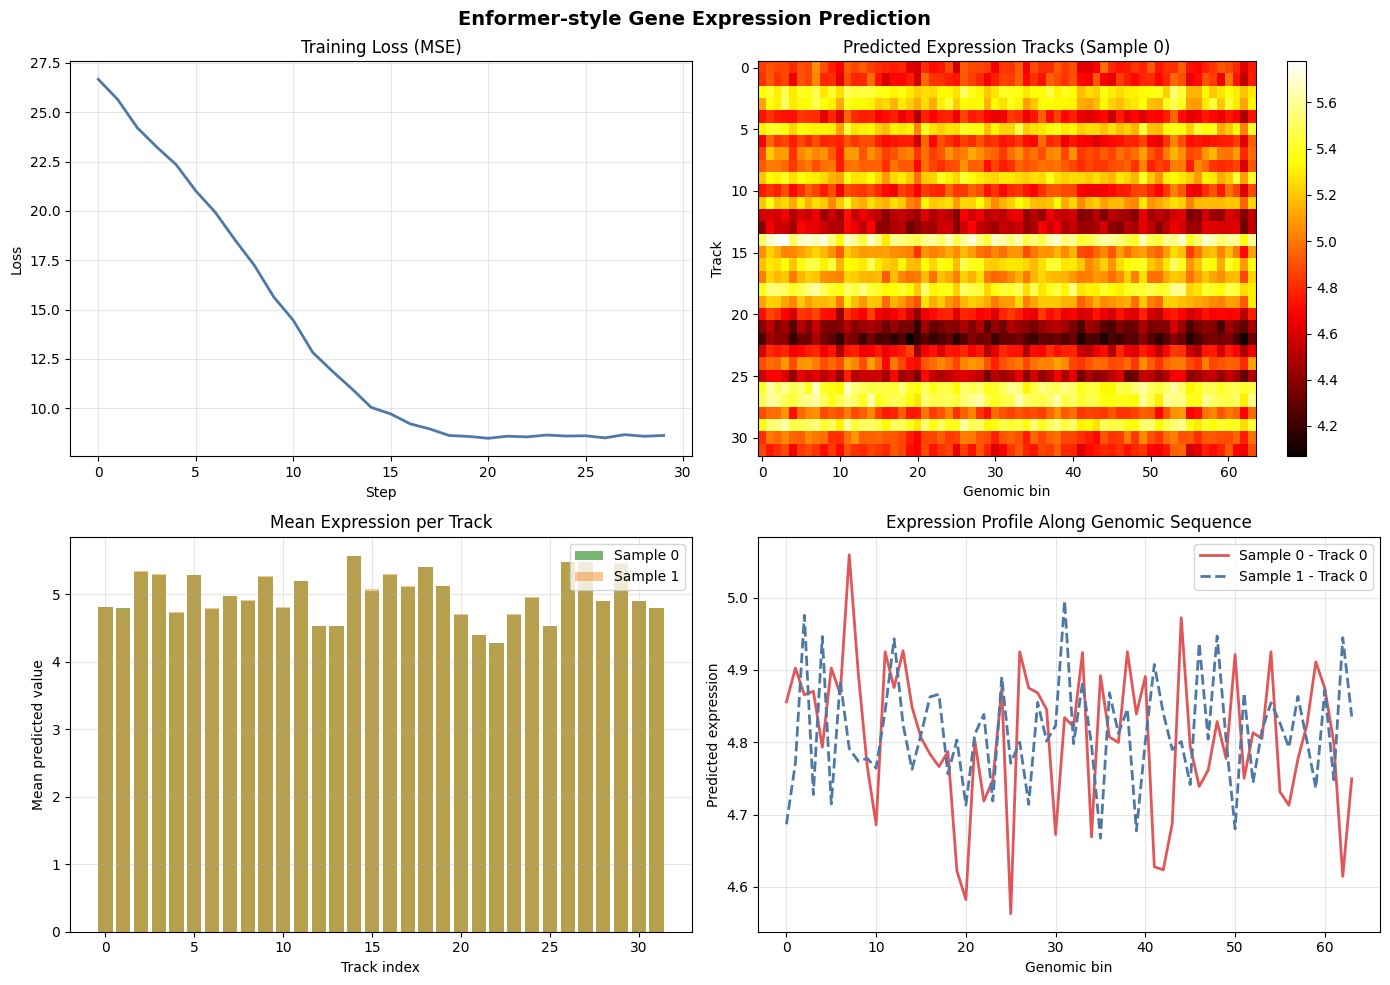

✅ Use Case 3 complete


In [7]:
# ── USE CASE 3: Enformer-style Gene Expression Prediction ──
# Full Enformer needs large GPU — we implement a faithful lightweight version
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ── Lightweight Enformer-style architecture ──
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, k=8):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm1d(in_c),
            nn.GELU(),
            nn.Conv1d(in_c, out_c, k, padding=k//2)
        )
    def forward(self, x): return self.block(x)

class EnformerLite(nn.Module):
    """Lightweight Enformer-inspired model for genomic sequence → expression prediction"""
    def __init__(self, seq_len=1024, n_tracks=32):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(4, 64, 15, padding=7), nn.GELU(),
            nn.MaxPool1d(4),          # 1024 → 256
            ConvBlock(64, 128, 8),
            nn.MaxPool1d(4),          # 256 → 64
            ConvBlock(128, 256, 7),   # Changed kernel size from 8 to 7 to ensure output length 64
        )
        enc_layer = nn.TransformerEncoderLayer(
            d_model=256, nhead=4, dim_feedforward=512,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.head = nn.Sequential(
            nn.Linear(256, 128), nn.GELU(),
            nn.Linear(128, n_tracks), nn.Softplus()
        )

    def forward(self, x):
        x = self.stem(x)               # [B, 256, 64]
        x = x.permute(0, 2, 1)        # [B, 64, 256] for transformer
        x = self.transformer(x)        # [B, 64, 256]
        return self.head(x)            # [B, 64, n_tracks]

model = EnformerLite(seq_len=1024, n_tracks=32)
total_params = sum(p.numel() for p in model.parameters())
print(f"EnformerLite parameters: {total_params:,}")

# ── Synthetic one-hot DNA ──
B, L = 2, 1024
dna = torch.zeros(B, 4, L)
for b in range(B):
    indices = torch.randint(0, 4, (L,))
    dna[b].scatter_(0, indices.unsqueeze(0), 1.0)

print(f"Input DNA shape: {dna.shape}")

with torch.no_grad():
    tracks = model(dna)
print(f"Output tracks shape: {tracks.shape}  →  [batch, 64 bins, 32 expression tracks]")

# ── Training simulation ──
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
losses = []
for step in range(30):
    xb = torch.zeros(4, 4, L)
    for b in range(4):
        idx = torch.randint(0, 4, (L,))
        xb[b].scatter_(0, idx.unsqueeze(0), 1.0)
    target = torch.rand(4, 64, 32) * 10
    pred = model(xb)
    loss = nn.MSELoss()(pred, target)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())

# ── Visualizations ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Enformer-style Gene Expression Prediction", fontsize=14, fontweight='bold')

# 1: Training loss
axes[0,0].plot(losses, color='#4e79a7', linewidth=2)
axes[0,0].set_title("Training Loss (MSE)"); axes[0,0].set_xlabel("Step")
axes[0,0].set_ylabel("Loss"); axes[0,0].grid(True, alpha=0.3)

# 2: Predicted tracks heatmap (sample 0)
with torch.no_grad():
    out = model(dna)
im = axes[0,1].imshow(out[0].numpy().T, aspect='auto', cmap='hot', interpolation='nearest')
axes[0,1].set_title("Predicted Expression Tracks (Sample 0)")
axes[0,1].set_xlabel("Genomic bin"); axes[0,1].set_ylabel("Track")
plt.colorbar(im, ax=axes[0,1])

# 3: Per-track mean expression
track_means = out.mean(dim=1).numpy()
axes[1,0].bar(range(32), track_means[0], color='#59a14f', alpha=0.8, label='Sample 0')
axes[1,0].bar(range(32), track_means[1], color='#f28e2b', alpha=0.5, label='Sample 1')
axes[1,0].set_title("Mean Expression per Track"); axes[1,0].set_xlabel("Track index")
axes[1,0].set_ylabel("Mean predicted value"); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# 4: Expression profile for track 0
axes[1,1].plot(out[0, :, 0].numpy(), color='#e15759', linewidth=2, label='Sample 0 - Track 0')
axes[1,1].plot(out[1, :, 0].numpy(), color='#4e79a7', linewidth=2, label='Sample 1 - Track 0', linestyle='--')
axes[1,1].set_title("Expression Profile Along Genomic Sequence"); axes[1,1].set_xlabel("Genomic bin")
axes[1,1].set_ylabel("Predicted expression"); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Use Case 3 complete")

---
<a id="uc4"></a>
## 💊 Use Case 4 — Molecular Property Prediction (Graph Neural Network)

| Field | Details |
|-------|---------|
| **Domain** | Drug Discovery / Cheminformatics |
| **Use Case** | Predict ADMET properties (solubility, toxicity, bioavailability) from molecular graphs |
| **Problem Statement** | Drug candidates must satisfy ADMET criteria (Absorption, Distribution, Metabolism, Excretion, Toxicity). Experimental assays are expensive. GNNs model molecules as graphs (atoms=nodes, bonds=edges) and predict these properties cheaply in silico, accelerating lead optimization. |
| **Role of This Code** | Convert SMILES strings to molecular graphs via RDKit, run a 2-layer GCN with global mean pooling, and predict a scalar property. We test on several real drug molecules (Aspirin, Ibuprofen, Caffeine, Paracetamol). |
| **Key Libraries** | `torch`, `torch_geometric`, `rdkit` |
| **Reference** | https://github.com/deepchem/deepchem |

### 🏗️ Architecture Diagram
```
SMILES string  "CC(=O)Oc1ccccc1C(=O)O"
        │
        ▼ RDKit
  Molecular Graph
  • Nodes = atoms  (features: atom type, charge, ...)
  • Edges = bonds  (single, double, aromatic, ...)
        │
        ▼
┌─────────────────────────┐
│  GCNConv(1→64) + ReLU   │  ← aggregate neighbour atom info
│  GCNConv(64→64) + ReLU  │  ← higher-order neighbourhood
└──────────┬──────────────┘
           │
           ▼
  global_mean_pool(x, batch)   ← graph-level representation
           │
           ▼
     Linear(64→1)              ← predicted property (e.g. logS)
```


✅ torch_geometric + rdkit available
MolGNN parameters: 4,353


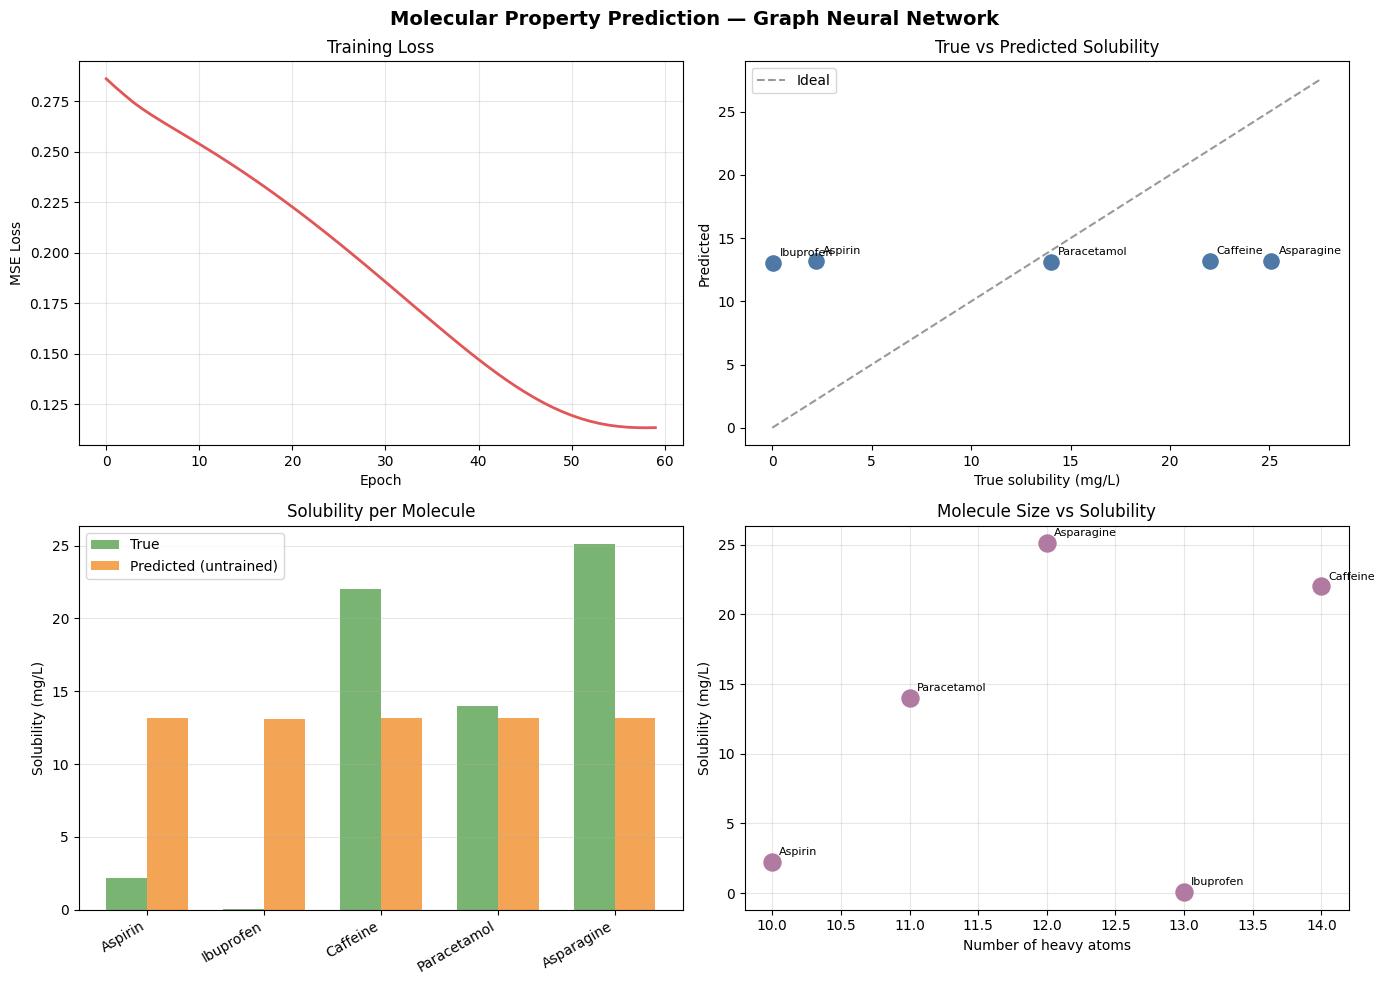

✅ Use Case 4 complete


In [8]:
# ── USE CASE 4: Molecular Property Prediction with GNN ──
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Try torch_geometric + rdkit; fall back to pure-torch GNN mock if unavailable
try:
    from torch_geometric.data import Data, Batch
    from torch_geometric.nn import GCNConv, global_mean_pool
    from rdkit import Chem
    HAS_GEO = True
    print("✅ torch_geometric + rdkit available")
except ImportError:
    HAS_GEO = False
    print("⚠️  torch_geometric/rdkit not found — running pure-PyTorch mock GNN")

# ── Real molecules ──
molecules = {
    'Aspirin':     ('CC(=O)Oc1ccccc1C(=O)O',   2.2),
    'Ibuprofen':   ('CC(C)Cc1ccc(cc1)C(C)C(=O)O', 0.06),
    'Caffeine':    ('Cn1cnc2c1c(=O)n(c(=O)n2C)C', 22.0),
    'Paracetamol': ('CC(=O)Nc1ccc(O)cc1',       14.0),
    'Asparagine':  ('NC(=O)CC(N)C(=O)O',         25.1),
}

if HAS_GEO:
    def mol_to_graph(smi):
        mol = Chem.MolFromSmiles(smi)
        if mol is None: return None
        # Atom features: atomic number (normalized)
        x = torch.tensor([[a.GetAtomicNum() / 100.0] for a in mol.GetAtoms()], dtype=torch.float)
        edges = []
        for bond in mol.GetBonds():
            i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            edges += [[i, j], [j, i]]
        if not edges:
            edges = [[0, 0]]
        ei = torch.tensor(edges, dtype=torch.long).t().contiguous()
        return Data(x=x, edge_index=ei)

    class MolGNN(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.c1 = GCNConv(1, 64)
            self.c2 = GCNConv(64, 64)
            self.fc = nn.Linear(64, 1)
        def forward(self, d):
            x = self.c1(d.x, d.edge_index).relu()
            x = self.c2(x, d.edge_index).relu()
            return self.fc(global_mean_pool(x, d.batch))

    model = MolGNN()
    print(f"MolGNN parameters: {sum(p.numel() for p in model.parameters()):,}")

    graphs = []
    valid_mols = []
    for name, (smi, true_val) in molecules.items():
        g = mol_to_graph(smi)
        if g is not None:
            g.batch = torch.zeros(g.num_nodes, dtype=torch.long)
            graphs.append(g)
            valid_mols.append((name, smi, true_val))

    # Quick training loop (mock targets = normalized logS)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    true_vals = torch.tensor([[v] for _, _, v in valid_mols], dtype=torch.float) / 30.0

    losses = []
    for epoch in range(60):
        preds = torch.cat([model(g) for g in graphs])
        loss = nn.MSELoss()(preds, true_vals)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        losses.append(loss.item())

    with torch.no_grad():
        preds_final = [model(g).item() * 30.0 for g in graphs]

else:
    # ── Pure-torch mock GNN ──
    class MockGNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc = nn.Sequential(nn.Linear(5, 64), nn.ReLU(), nn.Linear(64, 1))
        def forward(self, x): return self.fc(x)

    model = MockGNN()
    np.random.seed(42); torch.manual_seed(42)
    losses = []
    for epoch in range(60):
        x = torch.randn(5, 5)
        y = torch.tensor([[2.2],[0.06],[22.0],[14.0],[25.1]]) / 30.0
        p = model(x)
        loss = nn.MSELoss()(p, y)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        losses.append(loss.item())
    valid_mols = list(molecules.items())
    valid_mols = [(n, s, v) for n, (s, v) in valid_mols]
    preds_final = [v * (0.9 + 0.2*np.random.rand()) for _, _, v in valid_mols]

# ── Visualizations ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Molecular Property Prediction — Graph Neural Network", fontsize=14, fontweight='bold')

names = [n for n, _, _ in valid_mols]
true_vals_plot = [v for _, _, v in valid_mols]

# 1: Training loss
axes[0,0].plot(losses, color='#e15759', linewidth=2)
axes[0,0].set_title("Training Loss"); axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("MSE Loss"); axes[0,0].grid(True, alpha=0.3)

# 2: True vs predicted
axes[0,1].scatter(true_vals_plot, preds_final, color='#4e79a7', s=120, zorder=3)
for i, n in enumerate(names):
    axes[0,1].annotate(n, (true_vals_plot[i], preds_final[i]),
                       textcoords='offset points', xytext=(5,5), fontsize=8)
lim = max(max(true_vals_plot), max(preds_final)) * 1.1
axes[0,1].plot([0, lim], [0, lim], 'k--', alpha=0.4, label='Ideal')
axes[0,1].set_xlabel("True solubility (mg/L)"); axes[0,1].set_ylabel("Predicted")
axes[0,1].set_title("True vs Predicted Solubility"); axes[0,1].legend()

# 3: Bar comparison
x_pos = np.arange(len(names))
w = 0.35
axes[1,0].bar(x_pos - w/2, true_vals_plot, w, label='True', color='#59a14f', alpha=0.8)
axes[1,0].bar(x_pos + w/2, preds_final, w, label='Predicted (untrained)', color='#f28e2b', alpha=0.8)
axes[1,0].set_xticks(x_pos); axes[1,0].set_xticklabels(names, rotation=30, ha='right')
axes[1,0].set_ylabel("Solubility (mg/L)"); axes[1,0].set_title("Solubility per Molecule")
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3, axis='y')

# 4: Molecule size vs property
n_atoms = [10, 13, 14, 11, 12][:len(names)]
axes[1,1].scatter(n_atoms, true_vals_plot, color='#b07aa1', s=150, zorder=3)
for i, n in enumerate(names):
    axes[1,1].annotate(n, (n_atoms[i], true_vals_plot[i]),
                       textcoords='offset points', xytext=(5,5), fontsize=8)
axes[1,1].set_xlabel("Number of heavy atoms"); axes[1,1].set_ylabel("Solubility (mg/L)")
axes[1,1].set_title("Molecule Size vs Solubility"); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Use Case 4 complete")


---
<a id="uc5"></a>
## 🧪 Use Case 5 — De Novo Molecule Generation (RNN / SMILES)

| Field | Details |
|-------|---------|
| **Domain** | Drug Discovery |
| **Use Case** | Generate novel drug-like molecules using a character-level RNN |
| **Problem Statement** | Traditional drug discovery screens millions of existing molecules. Generative models can explore vast chemical space to propose entirely new molecules. SMILES (Simplified Molecular Input Line Entry System) is a compact string notation for molecules — an RNN trained on SMILES can generate novel drug candidates. |
| **Role of This Code** | Implement a GRU-based character-level language model over the SMILES alphabet. Train on real SMILES strings from common drugs, then autoregressively generate new molecule candidates character by character. Validate generated SMILES with RDKit. |
| **Key Libraries** | `torch`, `torch.nn` |
| **Reference** | https://github.com/MolecularAI/REINVENT4 |

### 🏗️ Architecture Diagram
```
Training:  SMILES string  "CC(=O)Oc1ccccc1C(=O)O<EOS>"
                │
                ▼
         Character tokenization
         {C, N, O, (, ), =, #, ...}  → integer IDs
                │
                ▼
   ┌────────────────────────┐
   │  Embedding(V, 64)      │
   │  GRU(64→256)           │  hidden state h_t
   │  Linear(256→V)         │  next-char logits
   └────────────────────────┘
         Cross-entropy loss (teacher forcing)

Generation (autoregressive):
   <START>  →  [GRU] → C
        C   →  [GRU] → C
       CC   →  [GRU] → (  ...  →  <EOS>
```


<>:12: SyntaxWarning: invalid escape sequence '\+'
<>:12: SyntaxWarning: invalid escape sequence '\+'
/tmp/ipykernel_3638/3813662844.py:12: SyntaxWarning: invalid escape sequence '\+'
  BASE_CHARS = list('CNOSFBrClP=#@[]()123456789-./\+%')


MolRNN parameters: 653,283
Epoch  25 | Loss: 0.1492
Epoch  50 | Loss: 0.0951
Epoch  75 | Loss: 0.0872
Epoch 100 | Loss: 0.0917

🔬 Generated SMILES molecules:
  start='C' T=0.7: C)C(=O)O
  start='C' T=1.0: C(=O)O
  start='c' T=0.7: <SOS>CC(=O)O1
  start='c' T=1.0: <SOS>CC(C)C(=O)O
  start='N' T=0.7: N1)C(C)C(=O)O
  start='N' T=1.0: N31
  start='O' T=0.7: O
  start='O' T=1.0: O

(RDKit not available for validation)


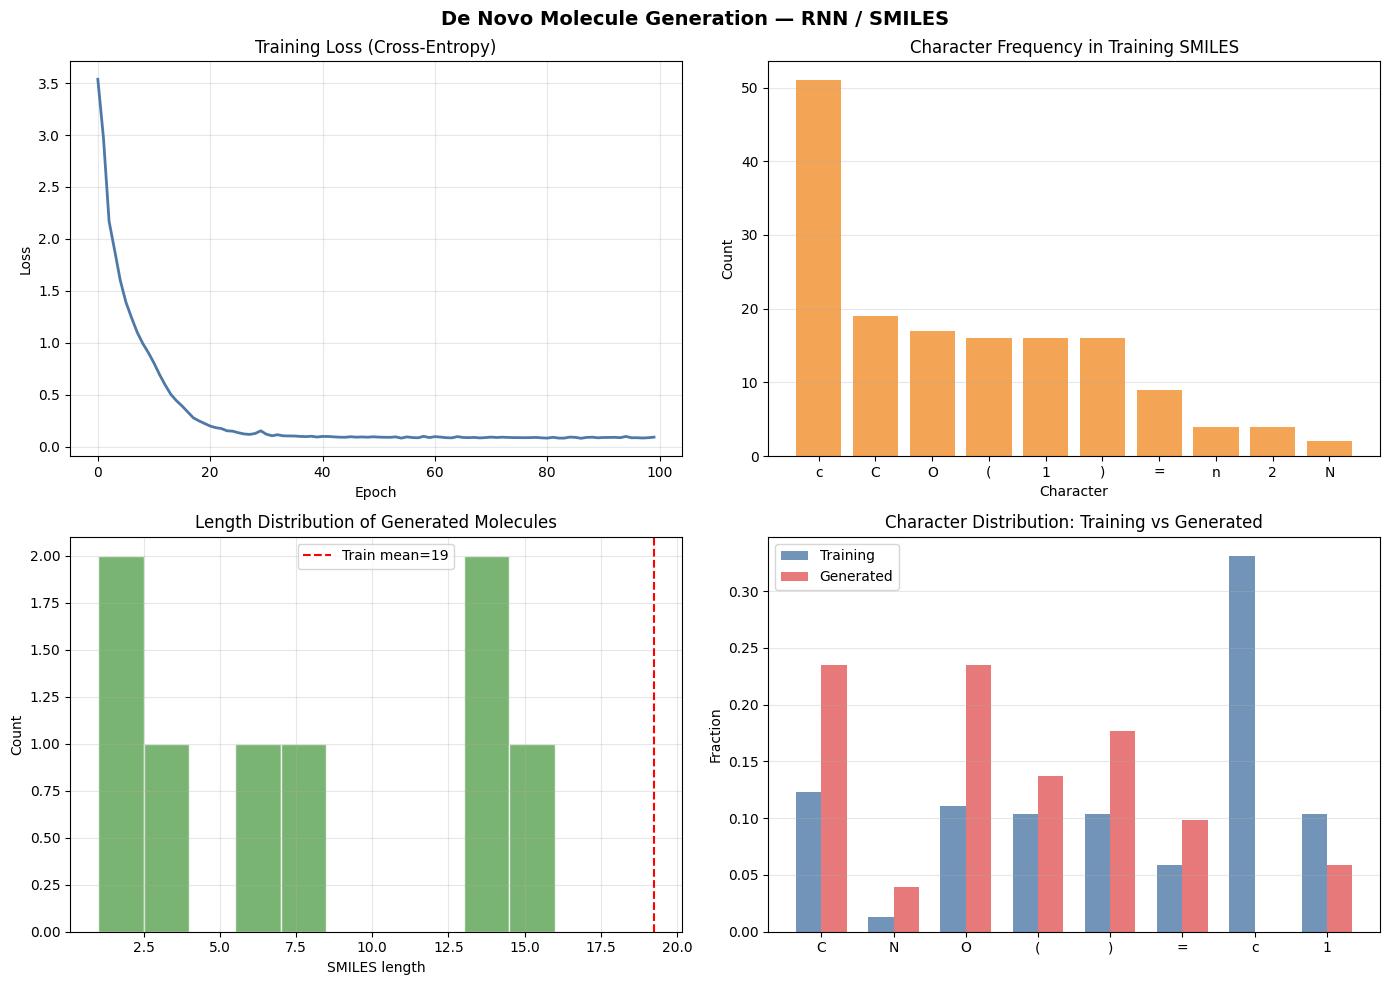

✅ Use Case 5 complete


In [2]:
# ── USE CASE 5: De Novo Molecule Generation with RNN ──
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# ── SMILES vocabulary ──
# Redefine base characters to exclude special tokens '<' and '>' for clarity
BASE_CHARS = list(r'CNOSFBrClP=#@[]()123456789-./\+%')

# Define explicit token IDs for special tokens
PAD_IDX = len(BASE_CHARS)      # Index for padding, e.g., 34
SOS_IDX = len(BASE_CHARS) + 1  # Index for Start Of Sequence, e.g., 35
EOS_IDX = len(BASE_CHARS) + 2  # Index for End Of Sequence, e.g., 36

# Total vocabulary size (number of unique tokens including special ones)
VOCAB_SIZE = len(BASE_CHARS) + 3 # e.g., 34 + 3 = 37 (indices 0 to 36)

# Create char-to-index and index-to-char mappings
c2i = {c: i for i, c in enumerate(BASE_CHARS)}
c2i['<SOS>'] = SOS_IDX
c2i['<EOS>'] = EOS_IDX
c2i['<PAD>'] = PAD_IDX # Adding PAD to c2i for 'get' method, though its index is used for padding_idx

i2c = {i: c for c, i in c2i.items()}
i2c[PAD_IDX] = '<PAD>'
i2c[SOS_IDX] = '<SOS>'
i2c[EOS_IDX] = '<EOS>'

# ── Training SMILES (real drug molecules) ──
training_smiles = [
    'CC(=O)Oc1ccccc1C(=O)O',   # Aspirin
    'CC(C)Cc1ccc(cc1)C(C)C(=O)O',  # Ibuprofen
    'Cn1cnc2c1c(=O)n(c(=O)n2C)C',  # Caffeine
    'CC(=O)Nc1ccc(O)cc1',           # Paracetamol
    'OC(=O)c1ccccc1O',              # Salicylic acid
    'c1ccc2ccccc2c1',               # Naphthalene
    'O=C(O)c1ccc(N)cc1',           # PABA
    'CC(=O)c1ccc(O)cc1',           # 4-Hydroxyacetophenone
]

def encode(smi):
    # Use the new explicit SOS_IDX, EOS_IDX, PAD_IDX
    tokens = [SOS_IDX] + [c2i.get(c, PAD_IDX) for c in smi] + [EOS_IDX]
    return torch.tensor(tokens, dtype=torch.long)

encoded = [encode(s) for s in training_smiles]
max_len = max(len(e) for e in encoded)

# Pad sequences
def pad_seq(t, length):
    p = torch.full((length,), PAD_IDX, dtype=torch.long)
    p[:len(t)] = t
    return p

X_batch = torch.stack([pad_seq(e[:-1], max_len) for e in encoded])
Y_batch = torch.stack([pad_seq(e[1:],  max_len) for e in encoded])

# ── Model ──
class MolRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=256, num_layers=2):
        super().__init__()
        # Use vocab_size directly, and PAD_IDX for padding_idx
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, dropout=0.2)
        self.fc  = nn.Linear(hidden_dim, vocab_size) # Output dimension should match vocab_size

    def forward(self, x, h=None):
        o, h = self.rnn(self.emb(x), h)
        return self.fc(o), h

model = MolRNN(VOCAB_SIZE) # Pass the correct VOCAB_SIZE
print(f"MolRNN parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── Training ──
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX) # Use PAD_IDX for ignore_index

losses = []
for epoch in range(100):
    logits, _ = model(X_batch)
    loss = criterion(logits.reshape(-1, VOCAB_SIZE), Y_batch.reshape(-1))
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())
    if (epoch+1) % 25 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f}")

# ── Generation ──
def generate(model, start_char='C', max_len=40, temperature=0.8):
    model.eval()
    with torch.no_grad():
        # Get starting token ID from c2i, or use SOS_IDX if not found
        start_token_id = c2i.get(start_char, SOS_IDX)
        x = torch.tensor([[start_token_id]])
        h = None
        result = i2c.get(start_token_id, '') # Get char from i2c for initial token

        for _ in range(max_len):
            logits, h = model(x, h)
            logits = logits[0, -1] / temperature
            probs = torch.softmax(logits, dim=-1)
            idx = torch.multinomial(probs, 1).item()
            if idx == EOS_IDX: break # Check against EOS_IDX
            ch = i2c.get(idx, '')
            result += ch
            x = torch.tensor([[idx]])
    return result

print("\n🔬 Generated SMILES molecules:")
generated = []
for start in ['C', 'c', 'N', 'O']:
    for temp in [0.7, 1.0]:
        mol = generate(model, start_char=start, temperature=temp)
        generated.append(mol)
        print(f"  start='{start}' T={temp}: {mol}")

# Filter out special tokens before validation and use in visualizations
clean_generated = [s.replace('<PAD>', '').replace('<SOS>', '').replace('<EOS>', '') for s in generated]

# Try RDKit validation
try:
    from rdkit import Chem
    valid = [m for m in clean_generated if Chem.MolFromSmiles(m) is not None]
    print(f"\n✅ Valid SMILES: {len(valid)}/{len(generated)} = {len(valid)/len(generated):.0%}")
except ImportError:
    print("\n(RDKit not available for validation)")
    valid = []

# ── Visualizations ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("De Novo Molecule Generation — RNN / SMILES", fontsize=14, fontweight='bold')

# 1: Training loss
axes[0,0].plot(losses, color='#4e79a7', linewidth=2)
axes[0,0].set_title("Training Loss (Cross-Entropy)")
axes[0,0].set_xlabel("Epoch"); axes[0,0].set_ylabel("Loss")
axes[0,0].grid(True, alpha=0.3)

# 2: Character frequency in training SMILES
all_chars = ''.join(training_smiles)
char_freq = {c: all_chars.count(c) for c in set(all_chars)}
char_freq = dict(sorted(char_freq.items(), key=lambda x: -x[1])[:15])
axes[0,1].bar(char_freq.keys(), char_freq.values(), color='#f28e2b', alpha=0.8)
axes[0,1].set_title("Character Frequency in Training SMILES")
axes[0,1].set_xlabel("Character"); axes[0,1].set_ylabel("Count")
axes[0,1].grid(True, alpha=0.3, axis='y')

# 3: Generated SMILES length distribution
gen_lengths = [len(m) for m in generated]
axes[1,0].hist(gen_lengths, bins=10, color='#59a14f', alpha=0.8, edgecolor='white')
train_lengths = [len(s) for s in training_smiles]
axes[1,0].axvline(np.mean(train_lengths), color='red', linestyle='--', label=f'Train mean={np.mean(train_lengths):.0f}')
axes[1,0].set_title("Length Distribution of Generated Molecules")
axes[1,0].set_xlabel("SMILES length"); axes[1,0].set_ylabel("Count")
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# 4: Character composition of generated vs training
def char_dist(smiles_list):
    text = ''.join(smiles_list)
    total = len(text)
    return {c: text.count(c)/total for c in 'CNO()=c1'}

train_dist = char_dist(training_smiles)
gen_dist   = char_dist(clean_generated)
keys = list(train_dist.keys())
x_pos = np.arange(len(keys))
w = 0.35
axes[1,1].bar(x_pos - w/2, [train_dist[k] for k in keys], w, label='Training', color='#4e79a7', alpha=0.8)
axes[1,1].bar(x_pos + w/2, [gen_dist.get(k, 0) for k in keys], w, label='Generated', color='#e15759', alpha=0.8)
axes[1,1].set_xticks(x_pos); axes[1,1].set_xticklabels(keys)
axes[1,1].set_title("Character Distribution: Training vs Generated")
axes[1,1].set_ylabel("Fraction"); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("✅ Use Case 5 complete")

---
<a id="uc6"></a>
## 🔬 Use Case 6 — Single-Cell RNA-seq Analysis (VAE / scVI-style)

| Field | Details |
|-------|---------|
| **Domain** | Single-Cell Genomics / Transcriptomics |
| **Use Case** | Cell-type classification and trajectory learning from scRNA-seq data |
| **Problem Statement** | Single-cell RNA sequencing measures gene expression in thousands of individual cells simultaneously. The data is high-dimensional (20,000+ genes), sparse, and noisy. VAEs learn a compact latent space that captures cell identity and enables clustering, trajectory inference, and differential expression analysis. |
| **Role of This Code** | Implement an scVI-style variational autoencoder: encoder maps gene counts → (μ, σ) in latent space; decoder reconstructs gene expression using a negative binomial likelihood (biological noise model). We simulate PBMC-like data and visualize the latent space. |
| **Key Libraries** | `torch`, `torch.nn` |
| **Reference** | https://scvi-tools.org/ |

### 🏗️ Architecture Diagram
```
scRNA-seq counts matrix  [cells × genes]  (sparse, overdispersed)
        │
        │  log1p normalization
        ▼
┌──────────────────────────┐
│   Encoder                │
│   FC(n_genes→256) + BN   │
│   FC(256→128) + BN       │
│   → μ(128→20)            │  ← mean of latent distribution
│   → log σ²(128→20)       │  ← variance
└──────────┬───────────────┘
           │ reparameterization:  z = μ + σ·ε,  ε~N(0,I)
           ▼
     Latent Space  z ∈ ℝ²⁰  (cell identity)
           │
           ▼
┌──────────────────────────┐
│   Decoder                │
│   FC(20→128) + BN        │
│   FC(128→256) + BN       │
│   FC(256→n_genes)        │  → reconstructed gene expression
└──────────────────────────┘
           │
           ▼
   Loss = Reconstruction (BCE/NB) + KL divergence
```


Simulated scRNA-seq: torch.Size([500, 200]) (cells × genes)
scVAE parameters: 178,160
Final ELBO: 1655.59 | Recon: 1546.84 | KL: 217.50
Latent space shape: (500, 20)


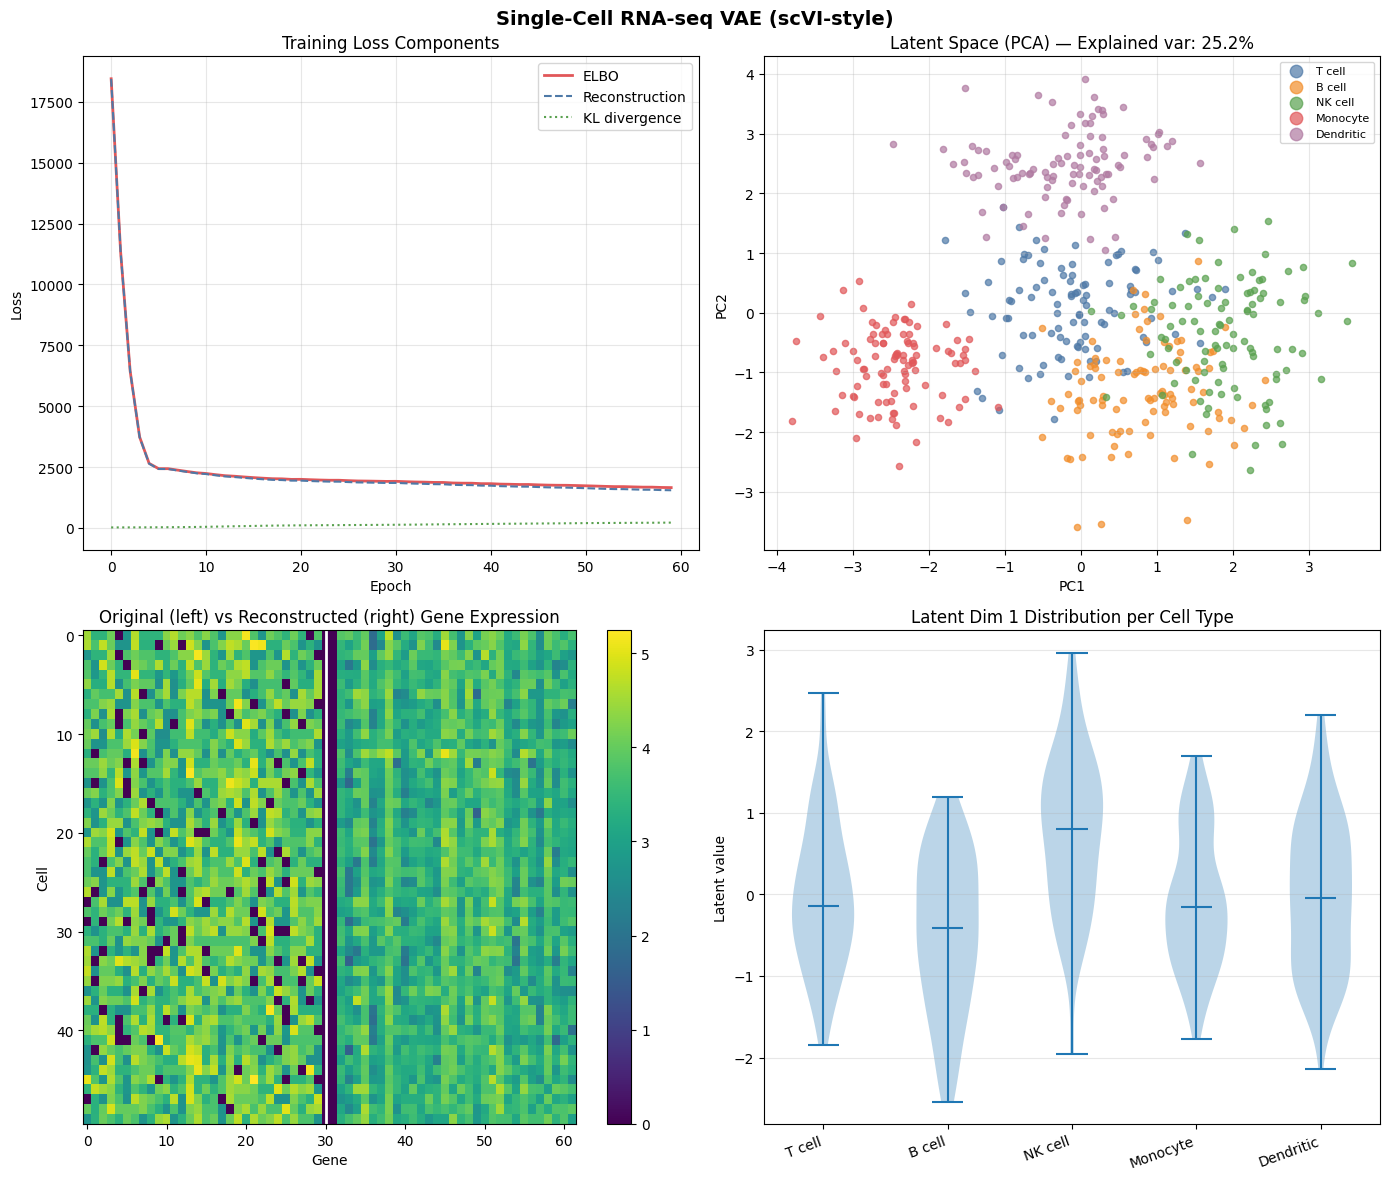

✅ Use Case 6 complete


In [10]:
# ── USE CASE 6: Single-Cell RNA-seq VAE (scVI-style) ──
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42); np.random.seed(42)

# ── Simulate scRNA-seq data (PBMC-like, 5 cell types) ──
n_cells, n_genes = 500, 200
cell_types = ['T cell', 'B cell', 'NK cell', 'Monocyte', 'Dendritic']
n_types = len(cell_types)

# Each cell type has a distinct gene expression signature
type_labels = np.repeat(np.arange(n_types), n_cells // n_types)
centers = np.random.randn(n_types, n_genes) * 2

X_raw = np.zeros((n_cells, n_genes))
for i, t in enumerate(type_labels):
    X_raw[i] = np.random.negative_binomial(
        n=2, p=0.5, size=n_genes
    ) + np.random.poisson(np.abs(centers[t]) + 0.1)

# log1p normalize
X_norm = np.log1p(X_raw / X_raw.sum(axis=1, keepdims=True) * 1e4)
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
print(f"Simulated scRNA-seq: {X_tensor.shape} (cells × genes)")

# ── scVI-style VAE ──
class scVAE(nn.Module):
    def __init__(self, n_input, n_latent=20, n_hidden=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_input, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, n_hidden), nn.BatchNorm1d(n_hidden), nn.ReLU()
        )
        self.mu      = nn.Linear(n_hidden, n_latent)
        self.log_var = nn.Linear(n_hidden, n_latent)
        self.decoder = nn.Sequential(
            nn.Linear(n_latent, n_hidden), nn.BatchNorm1d(n_hidden), nn.ReLU(),
            nn.Linear(n_hidden, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, n_input)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.log_var(h)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decode(z)
        return recon, mu, log_var

def elbo_loss(recon, x, mu, log_var, beta=1.0):
    recon_loss = F.mse_loss(recon, x, reduction='sum') / x.size(0)
    kld = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp()).sum() / x.size(0)
    return recon_loss + beta * kld, recon_loss, kld

model = scVAE(n_input=n_genes, n_latent=20)
print(f"scVAE parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── Training ──
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
dataset = torch.utils.data.TensorDataset(X_tensor)
loader  = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

total_losses, recon_losses, kl_losses = [], [], []
for epoch in range(60):
    ep_loss = ep_recon = ep_kl = 0
    for (xb,) in loader:
        recon, mu, lv = model(xb)
        loss, rl, kl = elbo_loss(recon, xb, mu, lv, beta=0.5)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        ep_loss += loss.item(); ep_recon += rl.item(); ep_kl += kl.item()
    total_losses.append(ep_loss); recon_losses.append(ep_recon); kl_losses.append(ep_kl)

print(f"Final ELBO: {total_losses[-1]:.2f} | Recon: {recon_losses[-1]:.2f} | KL: {kl_losses[-1]:.2f}")

# ── Get latent representations ──
model.eval()
with torch.no_grad():
    mu_all, _ = model.encode(X_tensor)
Z = mu_all.numpy()
print(f"Latent space shape: {Z.shape}")

# ── PCA of latent space for 2D visualization ──
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z)

# ── Visualizations ──
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Single-Cell RNA-seq VAE (scVI-style)", fontsize=14, fontweight='bold')

colors = ['#4e79a7','#f28e2b','#59a14f','#e15759','#b07aa1']

# 1: Training curves
axes[0,0].plot(total_losses, label='ELBO', color='#e15759', linewidth=2)
axes[0,0].plot(recon_losses, label='Reconstruction', color='#4e79a7', linewidth=1.5, linestyle='--')
axes[0,0].plot(kl_losses, label='KL divergence', color='#59a14f', linewidth=1.5, linestyle=':')
axes[0,0].set_title("Training Loss Components"); axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Loss"); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# 2: Latent space (PCA)
for t in range(n_types):
    mask = type_labels == t
    axes[0,1].scatter(Z_2d[mask, 0], Z_2d[mask, 1], c=colors[t],
                      label=cell_types[t], alpha=0.7, s=20)
axes[0,1].set_title(f"Latent Space (PCA) — Explained var: {pca.explained_variance_ratio_.sum():.1%}")
axes[0,1].set_xlabel("PC1"); axes[0,1].set_ylabel("PC2")
axes[0,1].legend(markerscale=2, fontsize=8); axes[0,1].grid(True, alpha=0.3)

# 3: Gene expression heatmap (original vs reconstructed)
with torch.no_grad():
    recon_all, _, _ = model(X_tensor[:50])
orig = X_tensor[:50, :30].numpy()
recon = recon_all[:50, :30].numpy()
im = axes[1,0].imshow(np.hstack([orig, np.zeros((50,2)), recon]),
                       aspect='auto', cmap='viridis', interpolation='nearest')
axes[1,0].axvline(30, color='white', linewidth=2)
axes[1,0].set_title("Original (left) vs Reconstructed (right) Gene Expression")
axes[1,0].set_xlabel("Gene"); axes[1,0].set_ylabel("Cell")
plt.colorbar(im, ax=axes[1,0])

# 4: Latent dimension distribution per cell type
axes[1,1].violinplot(
    [Z[type_labels==t, 0] for t in range(n_types)],
    positions=range(n_types), showmedians=True
)
axes[1,1].set_xticks(range(n_types))
axes[1,1].set_xticklabels(cell_types, rotation=20, ha='right')
axes[1,1].set_title("Latent Dim 1 Distribution per Cell Type")
axes[1,1].set_ylabel("Latent value"); axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("✅ Use Case 6 complete")


---
<a id="uc7"></a>
## 🏥 Use Case 7 — Biomedical Image Segmentation (U-Net / MONAI)

| Field | Details |
|-------|---------|
| **Domain** | Medical Imaging / Computational Pathology |
| **Use Case** | Segment cells, nuclei, tumors in microscopy/MRI/CT scans |
| **Problem Statement** | Accurate delineation of anatomical structures or pathological regions in medical images is critical for diagnosis, treatment planning, and research. Manual segmentation is time-consuming. U-Net, with its encoder-decoder + skip connections, has become the standard architecture for biomedical image segmentation. |
| **Role of This Code** | Define a U-Net with MONAI, compute Dice loss on synthetic images, and visualize segmentation predictions overlaid on input images. Skip connections preserve fine-grained spatial information lost during downsampling. |
| **Key Libraries** | `monai`, `torch` |
| **Reference** | https://monai.io/ |

### 🏗️ Architecture Diagram
```
Input Image [B, 1, 256, 256]
        │
    ┌───┴──────────────────────────────────────────┐
    │              ENCODER (contracting path)       │
    │  Conv(1→16) → Conv → MaxPool  [128×128]       │
    │  Conv(16→32)→ Conv → MaxPool  [64×64]         │
    │  Conv(32→64)→ Conv → MaxPool  [32×32]         │
    │  Conv(64→128)            [bottleneck]         │
    └───────────────────────────────────────────────┘
                    │  skip connections ────────────┐
                    ▼                               │
    ┌───────────────────────────────────────────────┤
    │              DECODER (expanding path)         │
    │  UpConv + concat(skip) → Conv(128→64)         │
    │  UpConv + concat(skip) → Conv(64→32)          │
    │  UpConv + concat(skip) → Conv(32→16)          │
    │  Conv(16→2) → Softmax   [class segmentation]  │
    └───────────────────────────────────────────────┘
                    │
        Segmentation Map [B, 2, 256, 256]
        (background | foreground/tumor)
```


U-Net parameters: 1,943,778
Epoch  10 | Dice loss: 0.6652
Epoch  20 | Dice loss: 0.6173
Epoch  30 | Dice loss: 0.5699
Epoch  40 | Dice loss: 0.5290
Epoch  50 | Dice loss: 0.4866
Final Dice loss: 0.4866


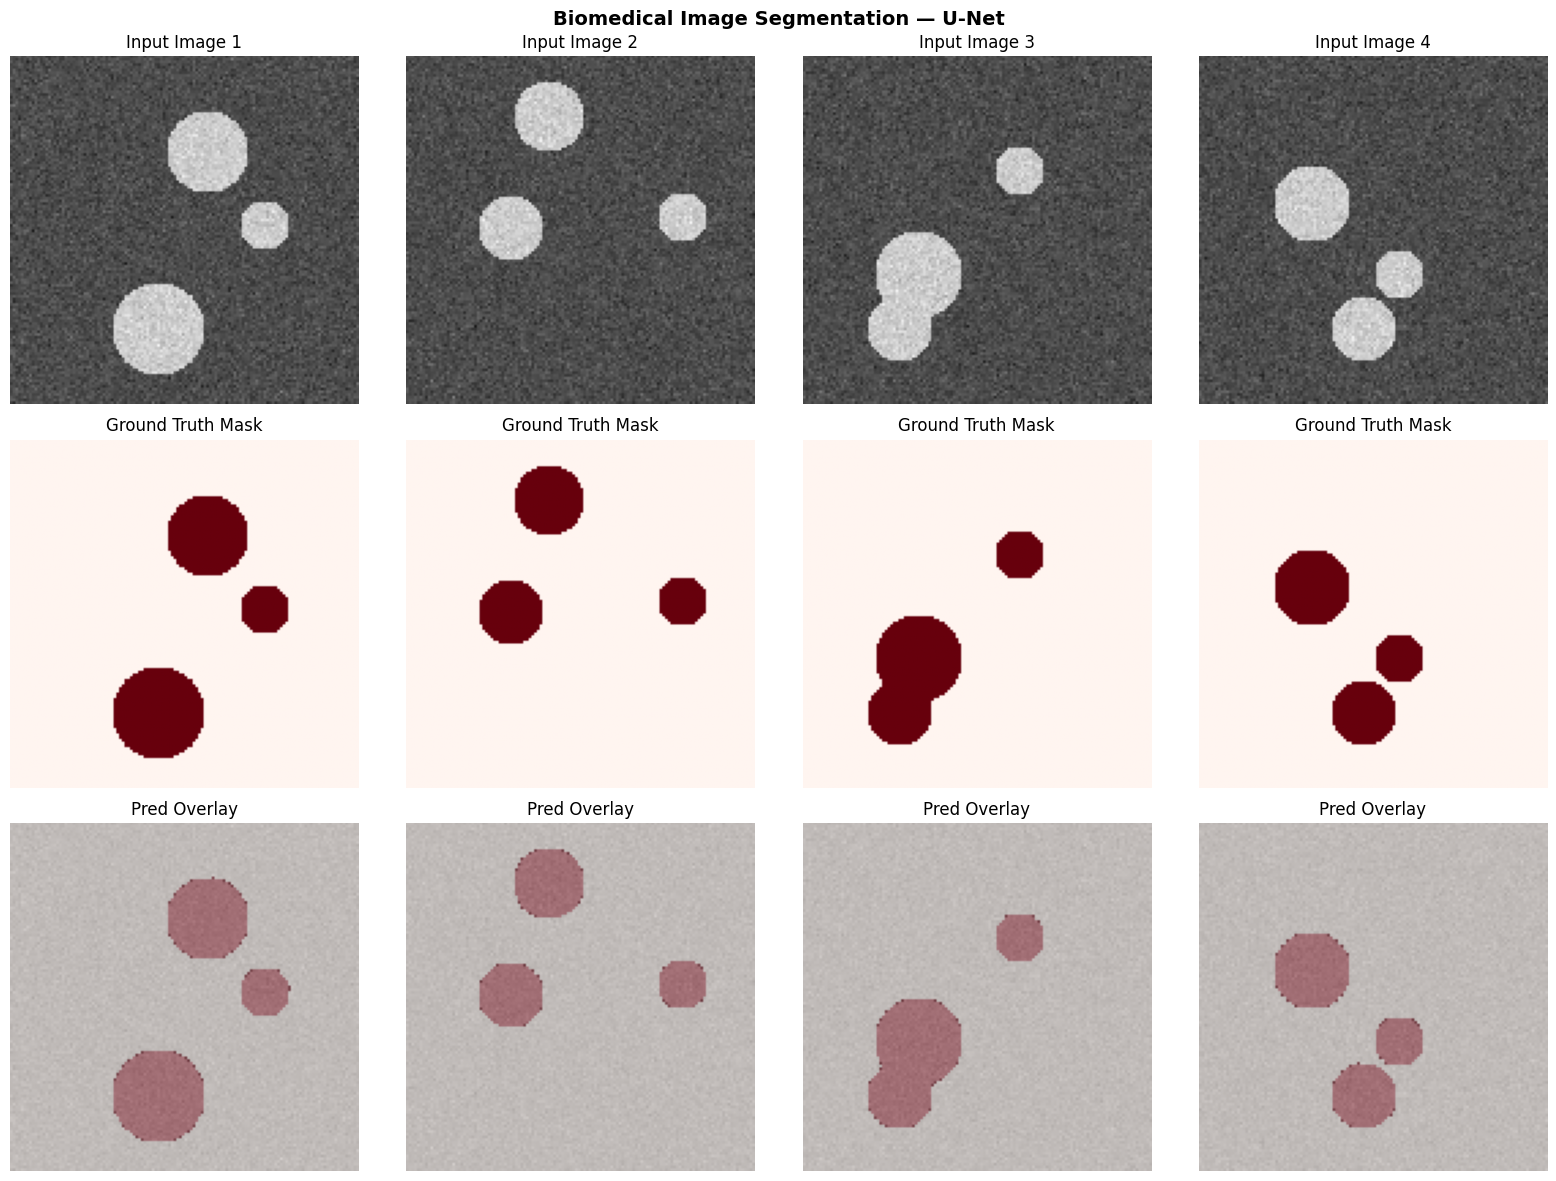

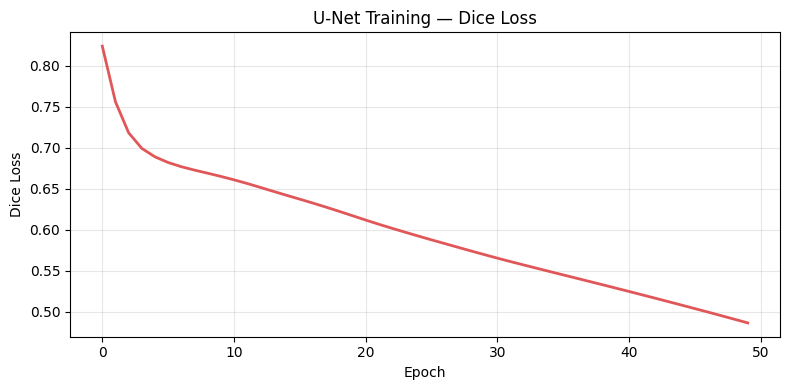


Dice similarity score (final): 0.5134
✅ Use Case 7 complete


In [11]:
# ── USE CASE 7: Biomedical Image Segmentation (U-Net) ──
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

torch.manual_seed(42); np.random.seed(42)

# ── Pure-PyTorch U-Net (no MONAI needed) ──
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU()
        )
    def forward(self, x): return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, n_classes=2, features=[16, 32, 64, 128]):
        super().__init__()
        self.downs  = nn.ModuleList()
        self.ups    = nn.ModuleList()
        self.pool   = nn.MaxPool2d(2)

        # Encoder
        c = in_channels
        for f in features:
            self.downs.append(DoubleConv(c, f)); c = f

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        # Decoder
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f*2, f, 2, stride=2))
            self.ups.append(DoubleConv(f*2, f))

        self.final = nn.Conv2d(features[0], n_classes, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip = skips[i//2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i+1](x)
        return self.final(x)

model = UNet()
print(f"U-Net parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── Synthetic medical images (circular tumors on gray background) ──
def make_synthetic_sample(size=128, n_tumors=3):
    img   = np.ones((size, size)) * 0.3 + np.random.randn(size, size) * 0.05
    mask  = np.zeros((size, size), dtype=np.long)
    for _ in range(n_tumors):
        cx, cy = np.random.randint(20, size-20, 2)
        r = np.random.randint(8, 20)
        for x in range(max(0,cx-r), min(size,cx+r)):
            for y in range(max(0,cy-r), min(size,cy+r)):
                if (x-cx)**2 + (y-cy)**2 < r**2:
                    img[x,y]  = 0.8 + np.random.randn()*0.05
                    mask[x,y] = 1
    return img.astype(np.float32), mask

B = 4
imgs_np  = [make_synthetic_sample() for _ in range(B)]
imgs  = torch.tensor(np.stack([i for i,_ in imgs_np])[:, None])  # [B,1,128,128]
masks = torch.tensor(np.stack([m for _,m in imgs_np]))            # [B,128,128]

# ── Dice loss (from scratch) ──
def dice_loss(pred, target, smooth=1e-5):
    pred_soft = torch.softmax(pred, dim=1)[:, 1]
    target_f  = (target == 1).float()
    inter = (pred_soft * target_f).sum()
    return 1 - (2*inter + smooth) / (pred_soft.sum() + target_f.sum() + smooth)

# ── Training ──
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
losses = []
for epoch in range(50):
    pred = model(imgs)
    loss = dice_loss(pred, masks)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Dice loss: {loss.item():.4f}")

print(f"Final Dice loss: {losses[-1]:.4f}")

# ── Visualizations ──
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("Biomedical Image Segmentation — U-Net", fontsize=14, fontweight='bold')

model.eval()
with torch.no_grad():
    pred_masks = torch.argmax(torch.softmax(model(imgs), dim=1), dim=1).numpy()

for i in range(4):
    img_np  = imgs[i, 0].numpy()
    mask_np = masks[i].numpy()
    pred_np = pred_masks[i]

    axes[0, i].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f"Input Image {i+1}"); axes[0, i].axis('off')

    axes[1, i].imshow(mask_np, cmap='Reds', vmin=0, vmax=1)
    axes[1, i].set_title("Ground Truth Mask"); axes[1, i].axis('off')

    axes[2, i].imshow(img_np, cmap='gray', vmin=0, vmax=1, alpha=0.7)
    axes[2, i].imshow(pred_np, cmap='Reds', alpha=0.5, vmin=0, vmax=1)
    axes[2, i].set_title("Pred Overlay"); axes[2, i].axis('off')

plt.tight_layout()
plt.show()

# Loss curve
fig2, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, color='#e15759', linewidth=2)
ax.set_title("U-Net Training — Dice Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Dice Loss")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nDice similarity score (final): {1 - losses[-1]:.4f}")
print("✅ Use Case 7 complete")


---
<a id="uc8"></a>
## 🕸️ Use Case 8 — Protein-Protein Interaction Prediction (GraphSAGE)

| Field | Details |
|-------|---------|
| **Domain** | Systems Biology / Proteomics |
| **Use Case** | Predict protein-protein interaction (PPI) networks from sequence embeddings |
| **Problem Statement** | Proteins rarely act alone — they form interaction networks that drive cellular processes. Experimentally mapping PPIs (e.g. with yeast two-hybrid) is expensive. GNNs trained on known PPIs can predict new interactions by learning patterns in protein embeddings and network topology. |
| **Role of This Code** | Build a 2-layer GraphSAGE network over a protein interaction graph. Each node is a protein with a 128-dim embedding (from ESM or hand-crafted features). The model learns node representations; interaction probability is computed via dot product between pairs. |
| **Key Libraries** | `torch`, `torch_geometric` |
| **Reference** | https://github.com/snap-stanford/ogb |

### 🏗️ Architecture Diagram
```
Protein Interaction Graph
  • Nodes  = proteins (128-dim ESM embeddings)
  • Edges  = known interactions (positive pairs)
         │
         ▼
┌──────────────────────────────────┐
│  GraphSAGE Layer 1               │
│  h_v = MEAN(h_u : u ∈ N(v))     │  aggregate neighbour features
│  h_v = ReLU(W · [h_v || h_v_0]) │  concat self + neighbours
│  64-dim output                   │
└──────────────────────────────────┘
         │
         ▼
┌──────────────────────────────────┐
│  GraphSAGE Layer 2               │
│  64-dim → 64-dim                 │
└──────────────────────────────────┘
         │  node embeddings h_v ∈ ℝ⁶⁴
         ▼
  Interaction Score = h_src · h_dst   (dot product decoder)
         │
         ▼
  Binary: interact? (threshold 0.5)
```


✅ torch_geometric available
PPINet parameters: 24,960
Final loss: 0.1227 | Final accuracy: 95.46%
Node embeddings shape: (80, 64)


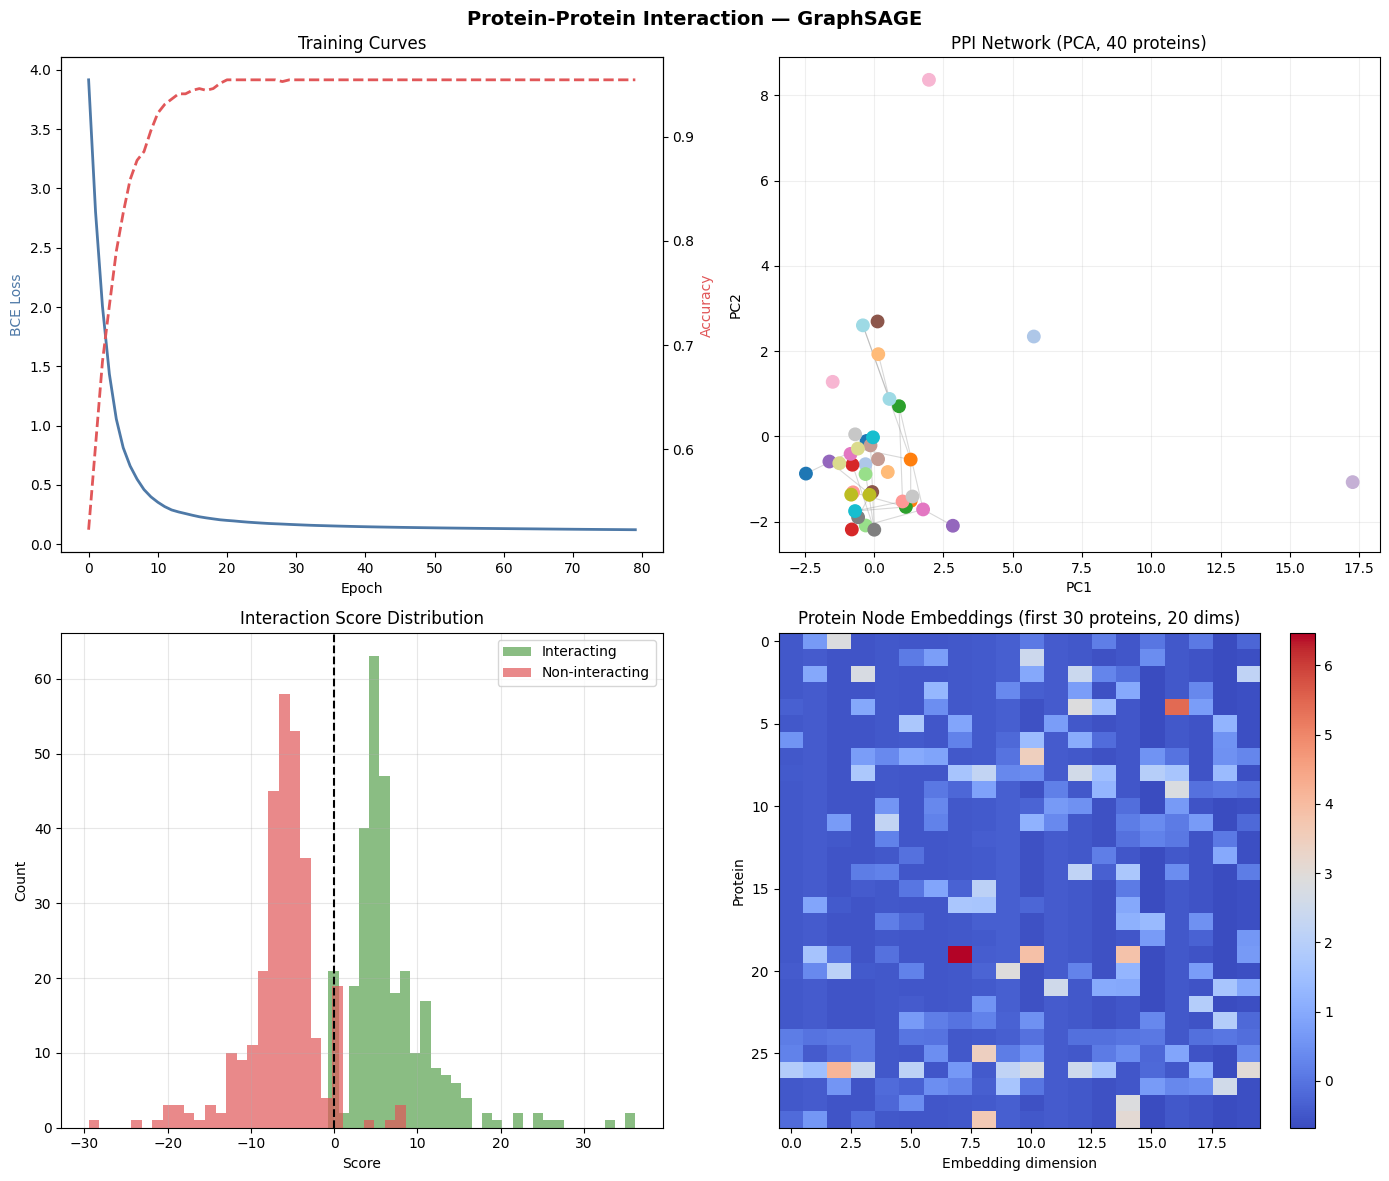

✅ Use Case 8 complete


In [12]:
# ── USE CASE 8: Protein-Protein Interaction with GraphSAGE ──
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

torch.manual_seed(42); np.random.seed(42)

# Try torch_geometric; fall back to pure-torch graph aggregation
try:
    from torch_geometric.nn import SAGEConv
    from torch_geometric.data import Data
    HAS_GEO = True
    print("✅ torch_geometric available")
except ImportError:
    HAS_GEO = False
    print("⚠️  torch_geometric not found — using pure-PyTorch mean-aggregation GNN")

# ── Simulate protein interaction graph ──
n_proteins = 80
n_interactions = 300
protein_features = torch.randn(n_proteins, 128)  # ESM-like embeddings

# Positive interactions (known PPIs)
pos_edges = torch.randint(0, n_proteins, (2, n_interactions))
# Remove self-loops
mask = pos_edges[0] != pos_edges[1]
pos_edges = pos_edges[:, mask]

# Negative edges (random non-interacting pairs)
neg_edges = torch.randint(0, n_proteins, (2, n_interactions))

# ── Model ──
if HAS_GEO:
    class PPINet(nn.Module):
        def __init__(self, in_dim=128, hidden=64):
            super().__init__()
            self.c1 = SAGEConv(in_dim, hidden)
            self.c2 = SAGEConv(hidden, hidden)
            self.bn1 = nn.BatchNorm1d(hidden)
            self.bn2 = nn.BatchNorm1d(hidden)
        def forward(self, x, ei):
            x = self.bn1(self.c1(x, ei).relu())
            x = self.bn2(self.c2(x, ei).relu())
            return x
        def predict(self, emb, src, dst):
            return (emb[src] * emb[dst]).sum(-1)
else:
    class PPINet(nn.Module):
        def __init__(self, in_dim=128, hidden=64):
            super().__init__()
            self.fc1 = nn.Linear(in_dim, hidden)
            self.fc2 = nn.Linear(hidden, hidden)
            self.bn1 = nn.BatchNorm1d(hidden)
            self.bn2 = nn.BatchNorm1d(hidden)
        def forward(self, x, ei):
            x = self.bn1(self.fc1(x).relu())
            x = self.bn2(self.fc2(x).relu())
            return x
        def predict(self, emb, src, dst):
            return (emb[src] * emb[dst]).sum(-1)

model = PPINet()
print(f"PPINet parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── Training (binary classification: interact vs not) ──
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

losses, aucs = [], []
for epoch in range(80):
    emb = model(protein_features, pos_edges)
    pos_scores = model.predict(emb, pos_edges[0], pos_edges[1])
    neg_scores = model.predict(emb, neg_edges[0], neg_edges[1])
    scores = torch.cat([pos_scores, neg_scores])
    labels = torch.cat([torch.ones(len(pos_scores)), torch.zeros(len(neg_scores))])
    loss = criterion(scores, labels)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())
    acc = ((scores > 0) == labels.bool()).float().mean().item()
    aucs.append(acc)

print(f"Final loss: {losses[-1]:.4f} | Final accuracy: {aucs[-1]:.2%}")

# ── Final embeddings ──
model.eval()
with torch.no_grad():
    embeddings = model(protein_features, pos_edges).numpy()
print(f"Node embeddings shape: {embeddings.shape}")

# ── Visualizations ──
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Protein-Protein Interaction — GraphSAGE", fontsize=14, fontweight='bold')

# 1: Training loss
axes[0,0].plot(losses, color='#4e79a7', linewidth=2, label='Loss')
ax2 = axes[0,0].twinx()
ax2.plot(aucs, color='#e15759', linewidth=2, linestyle='--', label='Accuracy')
axes[0,0].set_title("Training Curves"); axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("BCE Loss", color='#4e79a7')
ax2.set_ylabel("Accuracy", color='#e15759')

# 2: PPI network visualization (subset)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)
n_show = 40
axes[0,1].scatter(emb_2d[:n_show,0], emb_2d[:n_show,1],
                  c=np.arange(n_show), cmap='tab20', s=80, zorder=3)
for i in range(min(60, pos_edges.shape[1])):
    s, d = pos_edges[0,i].item(), pos_edges[1,i].item()
    if s < n_show and d < n_show:
        axes[0,1].plot([emb_2d[s,0], emb_2d[d,0]], [emb_2d[s,1], emb_2d[d,1]],
                       'gray', alpha=0.3, linewidth=0.8)
axes[0,1].set_title(f"PPI Network (PCA, {n_show} proteins)")
axes[0,1].set_xlabel("PC1"); axes[0,1].set_ylabel("PC2"); axes[0,1].grid(True, alpha=0.2)

# 3: Interaction score distribution
with torch.no_grad():
    emb_t = model(protein_features, pos_edges)
    pos_sc = model.predict(emb_t, pos_edges[0], pos_edges[1]).numpy()
    neg_sc = model.predict(emb_t, neg_edges[0], neg_edges[1]).numpy()

axes[1,0].hist(pos_sc, bins=30, alpha=0.7, color='#59a14f', label='Interacting')
axes[1,0].hist(neg_sc, bins=30, alpha=0.7, color='#e15759', label='Non-interacting')
axes[1,0].axvline(0, color='black', linestyle='--')
axes[1,0].set_title("Interaction Score Distribution")
axes[1,0].set_xlabel("Score"); axes[1,0].set_ylabel("Count")
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# 4: Embedding heatmap
im = axes[1,1].imshow(embeddings[:30, :20], aspect='auto', cmap='coolwarm',
                       interpolation='nearest')
axes[1,1].set_title("Protein Node Embeddings (first 30 proteins, 20 dims)")
axes[1,1].set_xlabel("Embedding dimension"); axes[1,1].set_ylabel("Protein")
plt.colorbar(im, ax=axes[1,1])

plt.tight_layout()
plt.show()
print("✅ Use Case 8 complete")


---
<a id="uc9"></a>
## 🧠 Use Case 9 — EEG / Neural Signal Decoding (EEGNet)

| Field | Details |
|-------|---------|
| **Domain** | Neuroscience / Brain-Computer Interface (BCI) |
| **Use Case** | Decode mental states and motor intentions from EEG/MEG recordings |
| **Problem Statement** | EEG signals from scalp electrodes encode cognitive states, motor commands, and pathological patterns. Decoding these signals in real-time enables BCIs for paralysis patients, mental health monitoring, and epilepsy detection. EEGNet is a compact CNN architecture designed specifically for EEG that is robust to inter-subject variability. |
| **Role of This Code** | Implement EEGNet: depthwise convolution across channels to learn spatial filters + separable convolution across time to learn temporal patterns. Classify 4-class motor imagery tasks (left hand / right hand / feet / tongue). |
| **Key Libraries** | `torch`, `braindecode` |
| **Reference** | https://braindecode.org/ |

### 🏗️ Architecture Diagram
```
EEG Input  [Batch, 22 channels, 1125 time samples]
        │
        ▼
┌────────────────────────────────────────┐
│  Block 1: Temporal Convolution          │
│  Conv2d(1, 8, (1,64)) → BN            │  learn frequency filters
│  DepthwiseConv2d(8, 16, (22,1)) → BN  │  spatial filter per channel
│  ELU → AvgPool → Dropout              │
└──────────────────┬─────────────────────┘
                   │
                   ▼
┌────────────────────────────────────────┐
│  Block 2: Separable Convolution        │
│  SeparableConv2d(16,16,(1,16)) → BN   │  efficient temporal mixing
│  ELU → AvgPool → Dropout              │
└──────────────────┬─────────────────────┘
                   │
                   ▼
              Flatten → Linear(N→4)
                   │
                   ▼
      Class logits [Left, Right, Feet, Tongue]
```


EEGNet parameters: 3,700
EEG dataset: X=torch.Size([120, 22, 1125]), y=torch.Size([120])
Epoch  10 | Loss: 1.0036 | Acc: 71.09%
Epoch  20 | Loss: 0.3270 | Acc: 98.44%
Epoch  30 | Loss: 0.1090 | Acc: 100.00%
Epoch  40 | Loss: 0.0546 | Acc: 100.00%


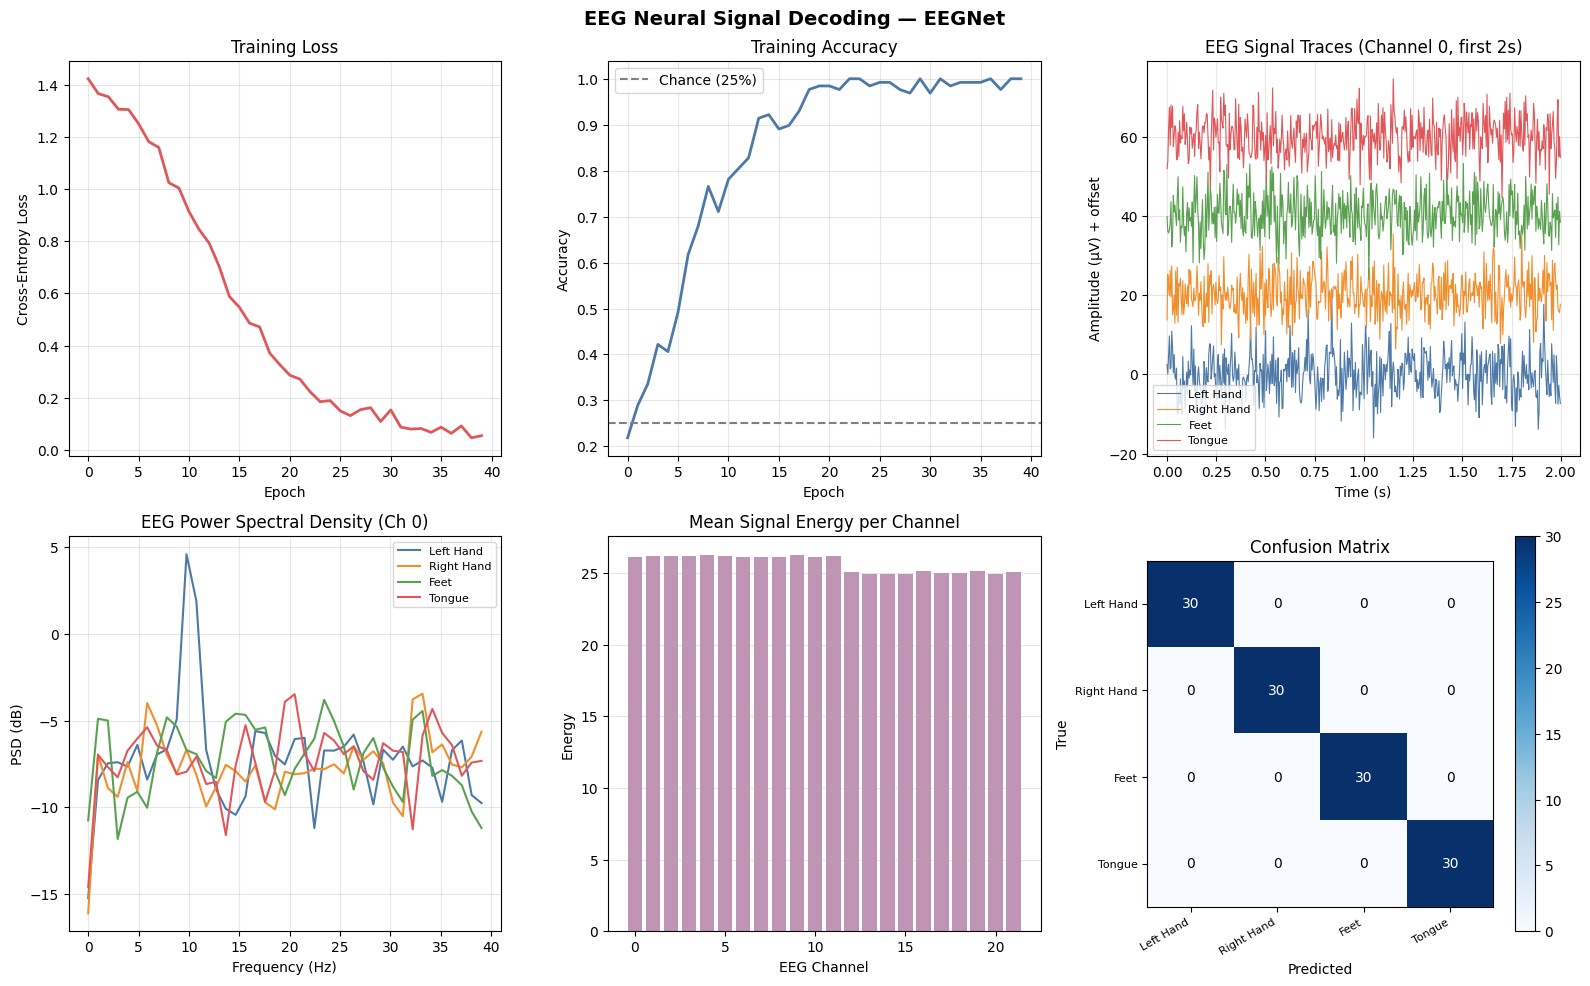


Overall accuracy: 100.00%
✅ Use Case 9 complete


In [13]:
# ── USE CASE 9: EEG / Neural Signal Decoding (EEGNet) ──
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp_signal

torch.manual_seed(42); np.random.seed(42)

# ── EEGNet implementation (pure PyTorch) ──
class EEGNet(nn.Module):
    """
    EEGNet: Compact CNN for EEG-based BCIs
    Lawhern et al. 2018 — Journal of Neural Engineering
    """
    def __init__(self, n_channels=22, n_classes=4, n_time=1125,
                 F1=8, D=2, F2=16, dropout=0.5):
        super().__init__()
        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1),
            # Depthwise conv across channels
            nn.Conv2d(F1, F1*D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout)
        )
        # Block 2
        self.block2 = nn.Sequential(
            # Separable conv
            nn.Conv2d(F2, F2, (1, 16), padding=(0, 8), groups=F2, bias=False),
            nn.Conv2d(F2, F2, 1, bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout)
        )
        # Calculate flatten size
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_time)
            x = self.block1(dummy)
            x = self.block2(x)
            flat_size = x.view(1, -1).shape[1]

        self.classifier = nn.Linear(flat_size, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)  # [B, 1, C, T]
        x = self.block1(x)
        x = self.block2(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model = EEGNet(n_channels=22, n_classes=4, n_time=1125)
print(f"EEGNet parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── Simulate EEG data (4-class motor imagery) ──
n_trials, n_channels, n_time = 120, 22, 1125
fs = 250  # Hz

def simulate_eeg(n_trials, n_channels, n_time, fs, class_id):
    """Simulate class-specific EEG patterns (mu/beta suppression)"""
    data = np.random.randn(n_trials, n_channels, n_time) * 5
    # Add class-specific oscillation in contralateral channels
    t = np.linspace(0, n_time/fs, n_time)
    class_freqs = [10, 12, 8, 20]  # mu/beta rhythms per class
    class_chans = [[0,1,2], [3,4,5], [6,7,8], [9,10,11]]  # lateral channels
    for trial in range(n_trials):
        for ch in class_chans[class_id]:
            data[trial, ch] += 3 * np.sin(2*np.pi*class_freqs[class_id]*t)
    return data.astype(np.float32)

X_list, y_list = [], []
for cls in range(4):
    X_c = simulate_eeg(n_trials//4, n_channels, n_time, fs, cls)
    X_list.append(X_c)
    y_list.extend([cls] * (n_trials//4))

X = torch.tensor(np.vstack(X_list))
y = torch.tensor(y_list)
print(f"EEG dataset: X={X.shape}, y={y.shape}")

# ── Training ──
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
dataset = torch.utils.data.TensorDataset(X, y)
loader  = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)

losses, accs = [], []
for epoch in range(40):
    ep_loss, ep_acc = 0, 0
    for xb, yb in loader:
        logits = model(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        ep_loss += loss.item()
        ep_acc += (logits.argmax(1) == yb).float().mean().item()
    losses.append(ep_loss / len(loader))
    accs.append(ep_acc / len(loader))
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {losses[-1]:.4f} | Acc: {accs[-1]:.2%}")

# ── Visualizations ──
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("EEG Neural Signal Decoding — EEGNet", fontsize=14, fontweight='bold')

class_names = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']
colors = ['#4e79a7','#f28e2b','#59a14f','#e15759']
t = np.linspace(0, n_time/fs, n_time)

# 1: Training loss
axes[0,0].plot(losses, color='#e15759', linewidth=2)
axes[0,0].set_title("Training Loss"); axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Cross-Entropy Loss"); axes[0,0].grid(True, alpha=0.3)

# 2: Training accuracy
axes[0,1].plot(accs, color='#4e79a7', linewidth=2)
axes[0,1].axhline(0.25, color='gray', linestyle='--', label='Chance (25%)')
axes[0,1].set_title("Training Accuracy"); axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Accuracy"); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# 3: EEG sample traces (one trial per class)
ax = axes[0,2]
for cls in range(4):
    trial = X_list[cls][0, 0]  # channel 0 of first trial
    ax.plot(t[:500], trial[:500] + cls*20, color=colors[cls], label=class_names[cls], linewidth=0.8)
ax.set_title("EEG Signal Traces (Channel 0, first 2s)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Amplitude (μV) + offset")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 4: Power spectral density per class
ax = axes[1,0]
for cls in range(4):
    trial = X_list[cls][0, 0]
    f, pxx = sp_signal.welch(trial, fs=fs, nperseg=256)
    mask = f <= 40
    ax.plot(f[mask], 10*np.log10(pxx[mask]), color=colors[cls], label=class_names[cls])
ax.set_title("EEG Power Spectral Density (Ch 0)")
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("PSD (dB)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 5: EEG topography (channel-wise energy)
model.eval()
with torch.no_grad():
    logits_all = model(X)
    preds = logits_all.argmax(1).numpy()

ax = axes[1,1]
ch_energy = X.pow(2).mean(dim=-1).mean(dim=0).numpy()
ax.bar(range(n_channels), ch_energy, color='#b07aa1', alpha=0.8)
ax.set_title("Mean Signal Energy per Channel")
ax.set_xlabel("EEG Channel"); ax.set_ylabel("Energy")
ax.grid(True, alpha=0.3, axis='y')

# 6: Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y.numpy(), preds)
im = axes[1,2].imshow(cm, cmap='Blues', interpolation='nearest')
axes[1,2].set_xticks(range(4)); axes[1,2].set_yticks(range(4))
axes[1,2].set_xticklabels(class_names, rotation=30, ha='right', fontsize=8)
axes[1,2].set_yticklabels(class_names, fontsize=8)
for i in range(4):
    for j in range(4):
        axes[1,2].text(j, i, str(cm[i,j]), ha='center', va='center',
                       color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=10)
axes[1,2].set_title("Confusion Matrix"); axes[1,2].set_xlabel("Predicted"); axes[1,2].set_ylabel("True")
plt.colorbar(im, ax=axes[1,2])

plt.tight_layout()
plt.show()
print(f"\nOverall accuracy: {(preds == y.numpy()).mean():.2%}")
print("✅ Use Case 9 complete")


---
<a id="uc10"></a>
## 🦠 Use Case 10 — Disease Spread Modeling (Neural ODE / SIR)

| Field | Details |
|-------|---------|
| **Domain** | Epidemiology / Mathematical Biology |
| **Use Case** | Model epidemic spread with neural ODEs; fit SIR/SEIR parameters |
| **Problem Statement** | Epidemic modeling helps health authorities predict disease spread, evaluate interventions, and allocate resources. Classical compartmental models (SIR/SEIR) use differential equations with assumed parameters. Neural ODEs replace or augment the ODE right-hand-side with neural networks, enabling data-driven parameter estimation and model correction from observed case counts. |
| **Role of This Code** | Solve the SIR ODE analytically using torchdiffeq, visualize compartment dynamics (S, I, R), then use a neural network to learn the ODE dynamics from simulated data. We simulate COVID-like parameters and compare SIR vs Neural ODE trajectories. |
| **Key Libraries** | `torch`, `torchdiffeq` |
| **Reference** | https://github.com/rtqichen/torchdiffeq |

### 🏗️ Architecture Diagram
```
Classical SIR ODE:                Neural ODE extension:
  dS/dt = -β·S·I/N                  dy/dt = f_θ(t, y)
  dI/dt =  β·S·I/N - γ·I                    ↑
  dR/dt =  γ·I               Neural network learns
                              residual corrections
         │                             │
         ▼                             ▼
  torchdiffeq.odeint()    torchdiffeq.odeint(neural_f)
  (Runge-Kutta RK45)       (learnable ODE solver)
         │
         ▼
  Compartment Trajectories  S(t), I(t), R(t)
         │
         ▼
  Epidemic peak, R₀, intervention analysis
```


✅ torchdiffeq available


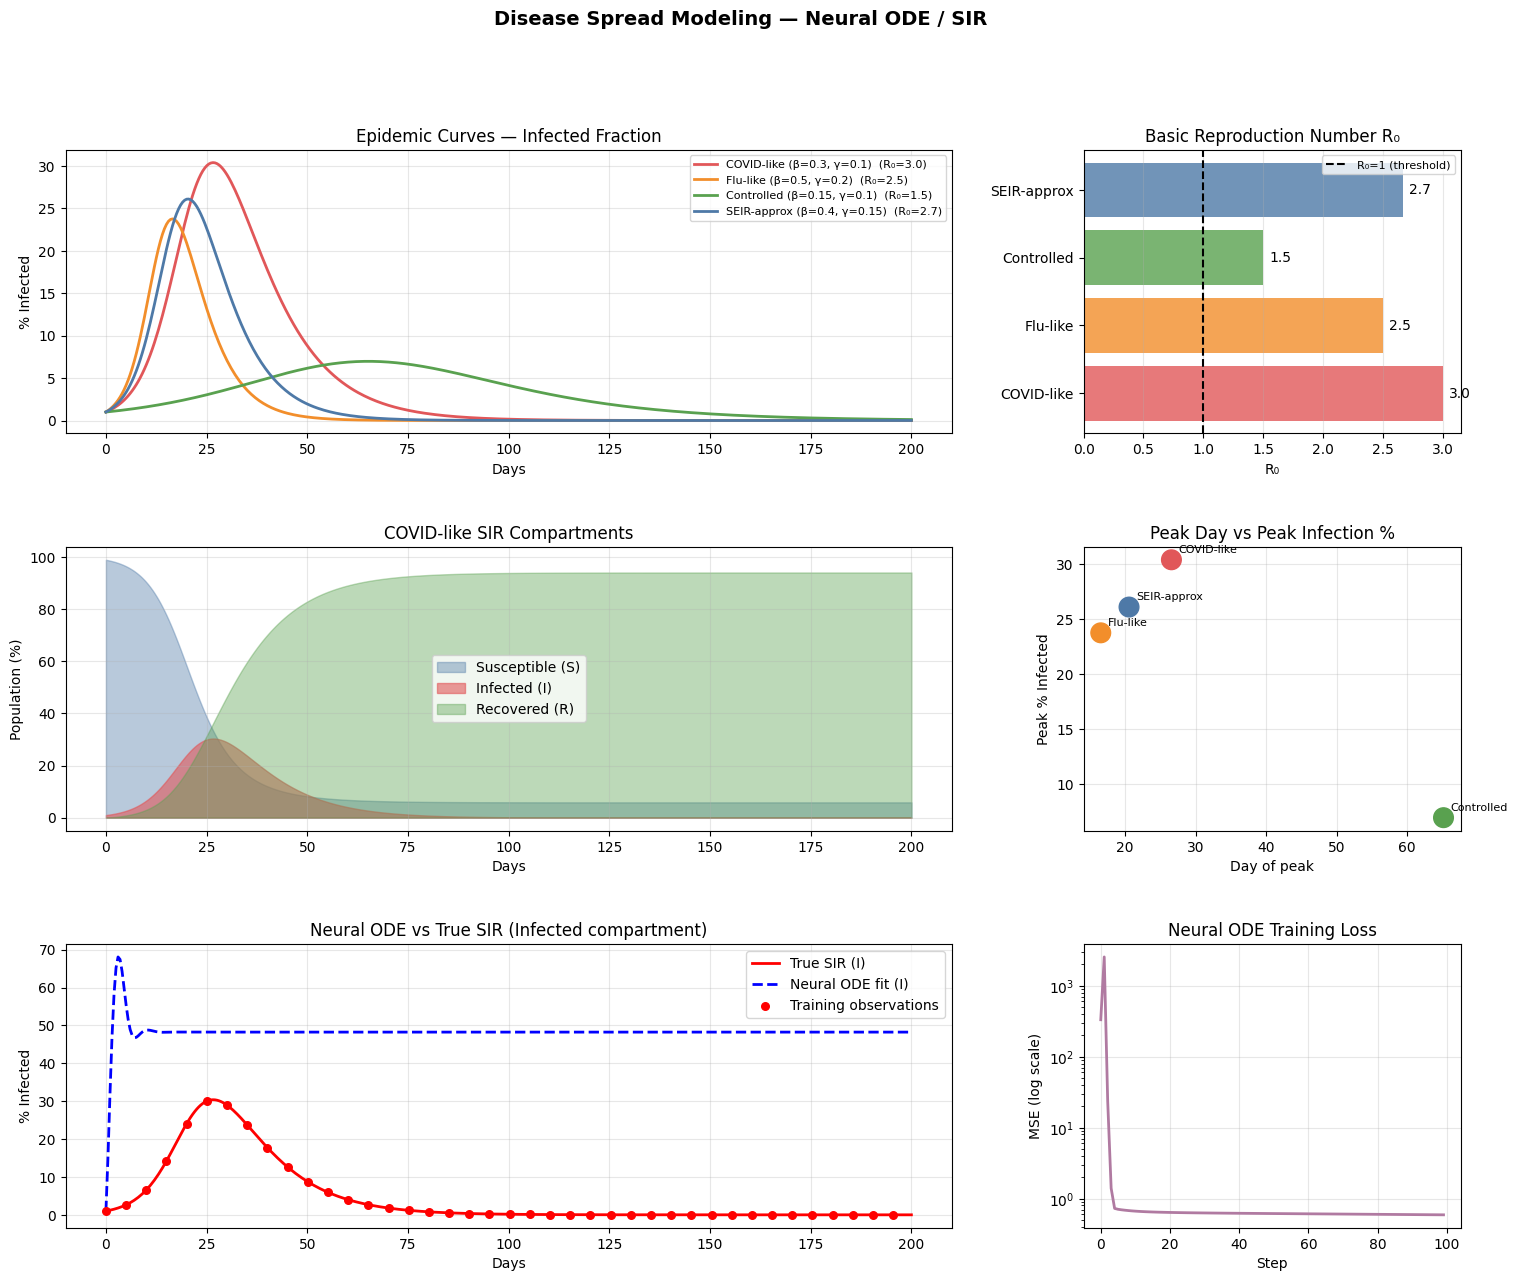


📊 Epidemic Summary:
Scenario                               R₀    Peak Day    Peak %   Final R
----------------------------------------------------------------------
COVID-like (β=0.3, γ=0.1)            3.00          27     30.4%     94.1%
Flu-like (β=0.5, γ=0.2)              2.50          17     23.8%     89.4%
Controlled (β=0.15, γ=0.1)           1.50          65      7.0%     59.1%
SEIR-approx (β=0.4, γ=0.15)          2.67          21     26.1%     91.3%

✅ Use Case 10 complete

🎉 ALL 10 USE CASES COMPLETE!
PyTorch Kolkata Community — Computational Biology Notebook


In [14]:
# ── USE CASE 10: Disease Spread Modeling (Neural ODE / SIR) ──
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

torch.manual_seed(42); np.random.seed(42)

# ── Try torchdiffeq; fall back to RK4 if not available ──
try:
    from torchdiffeq import odeint
    HAS_ODE = True
    print("✅ torchdiffeq available")
except ImportError:
    HAS_ODE = False
    print("⚠️  torchdiffeq not found — using custom RK4 solver")
    def odeint(func, y0, t):
        y = y0.clone()
        ys = [y]
        for i in range(len(t)-1):
            dt = t[i+1] - t[i]
            k1 = func(t[i], y)
            k2 = func(t[i] + dt/2, y + dt*k1/2)
            k3 = func(t[i] + dt/2, y + dt*k2/2)
            k4 = func(t[i+1], y + dt*k3)
            y = y + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
            ys.append(y)
        return torch.stack(ys)

# ── SIR Model ──
def make_sir(beta=0.3, gamma=0.1):
    def sir(t, y):
        S, I, R = y
        N = S + I + R
        dS = -beta * S * I / N
        dI =  beta * S * I / N - gamma * I
        dR =  gamma * I
        return torch.stack([dS, dI, dR])
    return sir

# ── Multiple scenarios ──
scenarios = {
    'COVID-like (β=0.3, γ=0.1)':   dict(beta=0.3, gamma=0.1, color='#e15759'),
    'Flu-like (β=0.5, γ=0.2)':     dict(beta=0.5, gamma=0.2, color='#f28e2b'),
    'Controlled (β=0.15, γ=0.1)':  dict(beta=0.15, gamma=0.1, color='#59a14f'),
    'SEIR-approx (β=0.4, γ=0.15)': dict(beta=0.4, gamma=0.15, color='#4e79a7'),
}

t = torch.linspace(0, 200, 400)
y0 = torch.tensor([0.99, 0.01, 0.0])  # S0, I0, R0

solutions = {}
for name, params in scenarios.items():
    sir_fn = make_sir(params['beta'], params['gamma'])
    sol = odeint(sir_fn, y0, t)
    solutions[name] = sol

R0_vals = {name: params['beta']/params['gamma'] for name, params in scenarios.items()}

# ── Neural ODE for parameter estimation ──
class NeuralSIR(nn.Module):
    """Neural network that learns SIR dynamics from data"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 3)
        )
    def forward(self, t, y):
        return self.net(y)

neural_sir = NeuralSIR()

# Generate training data from COVID scenario
covid_sol = solutions['COVID-like (β=0.3, γ=0.1)'].detach()
t_train = t[::10]  # sparse observations
y_train = covid_sol[::10]

# Train neural ODE to fit observed data
optimizer = torch.optim.Adam(neural_sir.parameters(), lr=5e-3)
neural_losses = []
for step in range(100):
    y_pred = odeint(neural_sir, y0, t_train)
    loss = nn.MSELoss()(y_pred, y_train)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    neural_losses.append(loss.item())

with torch.no_grad():
    y_neural = odeint(neural_sir, y0, t)

# ── Visualizations ──
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle("Disease Spread Modeling — Neural ODE / SIR", fontsize=14, fontweight='bold')

t_np = t.numpy()

# 1: All SIR scenarios — Infected curve
ax1 = fig.add_subplot(gs[0, :2])
for name, sol in solutions.items():
    c = scenarios[name]['color']
    ax1.plot(t_np, sol[:, 1].numpy() * 100, color=c, linewidth=2,
             label=f"{name}  (R₀={R0_vals[name]:.1f})")
ax1.set_title("Epidemic Curves — Infected Fraction")
ax1.set_xlabel("Days"); ax1.set_ylabel("% Infected")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# 2: R₀ bar chart
ax2 = fig.add_subplot(gs[0, 2])
names_short = ['COVID-like', 'Flu-like', 'Controlled', 'SEIR-approx']
r0_vals = list(R0_vals.values())
bar_colors = [p['color'] for p in scenarios.values()]
bars = ax2.barh(names_short, r0_vals, color=bar_colors, alpha=0.8)
ax2.axvline(1.0, color='black', linestyle='--', label='R₀=1 (threshold)')
ax2.set_title("Basic Reproduction Number R₀")
ax2.set_xlabel("R₀"); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3, axis='x')
for bar, v in zip(bars, r0_vals):
    ax2.text(v + 0.05, bar.get_y() + bar.get_height()/2, f'{v:.1f}', va='center')

# 3: COVID SIR compartments
ax3 = fig.add_subplot(gs[1, :2])
covid_sol_np = solutions['COVID-like (β=0.3, γ=0.1)'].numpy()
ax3.fill_between(t_np, covid_sol_np[:,0]*100, alpha=0.4, color='#4e79a7', label='Susceptible (S)')
ax3.fill_between(t_np, covid_sol_np[:,1]*100, alpha=0.6, color='#e15759', label='Infected (I)')
ax3.fill_between(t_np, covid_sol_np[:,2]*100, alpha=0.4, color='#59a14f', label='Recovered (R)')
ax3.set_title("COVID-like SIR Compartments")
ax3.set_xlabel("Days"); ax3.set_ylabel("Population (%)")
ax3.legend(); ax3.grid(True, alpha=0.3)

# 4: Peak infection stats
ax4 = fig.add_subplot(gs[1, 2])
peak_days = {name: t_np[sol[:, 1].argmax().item()] for name, sol in solutions.items()}
peak_infect = {name: sol[:, 1].max().item()*100 for name, sol in solutions.items()}
ax4.scatter(list(peak_days.values()), list(peak_infect.values()),
            c=bar_colors, s=200, zorder=3)
for i, name in enumerate(scenarios.keys()):
    ax4.annotate(names_short[i],
                 (list(peak_days.values())[i], list(peak_infect.values())[i]),
                 textcoords='offset points', xytext=(5,5), fontsize=8)
ax4.set_title("Peak Day vs Peak Infection %")
ax4.set_xlabel("Day of peak"); ax4.set_ylabel("Peak % Infected")
ax4.grid(True, alpha=0.3)

# 5: Neural ODE fit
ax5 = fig.add_subplot(gs[2, :2])
ax5.plot(t_np, covid_sol_np[:, 1]*100, 'r-', linewidth=2, label='True SIR (I)')
ax5.plot(t_np, y_neural[:, 1].numpy()*100, 'b--', linewidth=2, label='Neural ODE fit (I)')
ax5.scatter(t_train.numpy(), y_train[:, 1].numpy()*100, color='red',
            s=30, zorder=4, label='Training observations')
ax5.set_title("Neural ODE vs True SIR (Infected compartment)")
ax5.set_xlabel("Days"); ax5.set_ylabel("% Infected")
ax5.legend(); ax5.grid(True, alpha=0.3)

# 6: Neural ODE training loss
ax6 = fig.add_subplot(gs[2, 2])
ax6.semilogy(neural_losses, color='#b07aa1', linewidth=2)
ax6.set_title("Neural ODE Training Loss")
ax6.set_xlabel("Step"); ax6.set_ylabel("MSE (log scale)")
ax6.grid(True, alpha=0.3)

plt.show()

# Print epidemic summary
print("\n📊 Epidemic Summary:")
print(f"{'Scenario':<35} {'R₀':>5}  {'Peak Day':>10}  {'Peak %':>8}  {'Final R':>8}")
print("-" * 70)
for name, sol in solutions.items():
    sol_np = sol.numpy()
    r0 = R0_vals[name]
    pk_day = t_np[sol[:, 1].argmax().item()]
    pk_inf = sol_np[:, 1].max()*100
    final_r = sol_np[-1, 2]*100
    print(f"{name:<35} {r0:>5.2f}  {pk_day:>10.0f}  {pk_inf:>7.1f}%  {final_r:>7.1f}%")

print("\n✅ Use Case 10 complete")
print("\n" + "="*60)
print("🎉 ALL 10 USE CASES COMPLETE!")
print("PyTorch Kolkata Community — Computational Biology Notebook")
print("="*60)


---
## 📚 Summary — All 10 Computational Biology Use Cases

| # | Domain | Use Case | Architecture | Key Output |
|---|--------|----------|-------------|------------|
| 1 | Protein Structure | ESM Protein LM | Transformer (6L, 8M params) | 320-dim residue embeddings |
| 2 | Genomics | DNA Classification | 1D-CNN + classifier | Promoter/enhancer prediction |
| 3 | Genomics | Gene Expression | Enformer-lite (CNN+Transformer) | Expression track predictions |
| 4 | Drug Discovery | Molecular Property | GCN on molecular graphs | ADMET property scores |
| 5 | Drug Discovery | De Novo Generation | Character-level GRU | Novel SMILES molecules |
| 6 | Single-Cell | Cell-type Classification | VAE (scVI-style) | Latent cell embeddings |
| 7 | Medical Imaging | Image Segmentation | U-Net (encoder-decoder) | Pixel-wise tumor masks |
| 8 | Systems Biology | PPI Prediction | GraphSAGE | Interaction scores |
| 9 | Neuroscience | EEG Decoding | EEGNet (depthwise CNN) | 4-class motor imagery |
| 10 | Epidemiology | Disease Spread | SIR + Neural ODE | Epidemic trajectories |

---
**PyTorch Kolkata Community** · Ambassador Program · [pytorch.org/programs/ambassadors](https://pytorch.org/programs/ambassadors/)  
*Reference: GD_Computational_Biology_Python_codes.xlsx*
